# Стохастический градиентный спуск (20 баллов)

In [1]:
import os
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from torch.optim import Optimizer

import torchvision
from torchvision.datasets.utils import download_url
import torchvision.transforms as transforms
import seaborn as sns
sns.set()
%config InlineBackend.figure_format = 'retina'

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Основная часть (всего 10 баллов)

__Задача 1.__ В этой работе вы будете реализовывать стохастические методы на библиотеке torch. В основной части рассмотрим логистическую регрессию на [датасете](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/a9a) из библиотеки LIBSVM.

__а) (1 балл)__ Реализуйте класс `LIBSVM` для работы с данными во время обучения/валидации. Допишите метод инициализации класса:
1. С помощью функции `load_svmlight_file` распарсите файл, лежащий в директории `file_dir`;
2. Преобразуйте дата-матрицу $X$ в формат `torch.Tensor` (воспользуйтесь функцией `torch.from_numpy`);
3. Выполните нормализацию данных по второй норме для каждой строки;
3. Преобразуйте вектор меток $y$ в формат `torch.Tensor`, а также приведите метки к значениям 0 и 1;
4. Разделите данные на обучающую и тестовую выборки, используя `train_test_split` с параметром `random_state=57`;
5. Преобразованные данные сохраните в атрибутах `self.train_dataset` и `self.test_dataset` как элементы класса `TensorDataset` (достаточно подать преобразованные тензоры $X$ и $y$ в него).

In [3]:
DOWNLOAD_LINKS = {'a9a': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/a9a'}

class LIBSVM(Dataset):
    def __init__(self, root, dataset_name, download=True, test_size=0.2, random_state=57):
        download_link = DOWNLOAD_LINKS[dataset_name]
        target = os.path.basename(download_link)
        file_dir = os.path.join(root, target)

        if not os.path.exists(file_dir):
            if download:
                download_url(download_link, root)
            else:
                raise FileNotFoundError(f"{file_dir} не существует")

        X, y = load_svmlight_file(file_dir)
        X_torch = torch.from_numpy(X.toarray())
        X_torch = X_torch / (X_torch.norm(p=2, dim=1, keepdim=True) + 1e-12)
        y_torch = torch.from_numpy(y)
        mapping = {1 : 1, -1 : 0}
        mapped_list = [mapping[value.item()] for value in y_torch]
        y_torch = torch.Tensor(mapped_list)

        X_train, X_test, y_train, y_test = train_test_split(X_torch, y_torch, test_size=test_size, random_state=57)
        self.train_dataset = TensorDataset(X_train, y_train)
        self.test_dataset = TensorDataset(X_test, y_test)
        self.dataset = TensorDataset(X_torch, y_torch)


    def __getitem__(self, index):
        """
        Получение одного элемента из набора данных
        """
        return self.dataset.__getitem__(index)

    def __len__(self):
        """
        Количество элементов в наборе данных
        """
        return self.dataset.__len__()

In [4]:
test = LIBSVM(root='.', dataset_name='a9a')

100%|██████████| 2.33M/2.33M [00:00<00:00, 6.97MB/s]


__б) (1 балл)__ Создайте модель `LogisticRegression`, которая будет представлять из себя [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) без `bias` с функцией активации [`F.sigmoid`](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.sigmoid.html).

_Указание: необходимо выдавать одно значение — вероятность, что метка принадлежит 1 классу._

In [5]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1, bias = False)
        self.sigmoid = F.sigmoid

    def forward(self, x):
        return self.sigmoid(self.linear(x))

__в) (2 балла)__ Рассмотрите стохастический градиентный спуск (SGD). Допишите код метода. В нем должна быть реализована возможность использовать моментум (параметр `momentum`), а также $L_2$-регуляризацию для каждого параметра (параметр `weight_decay`).

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^0 \in \mathbb{R}^d$
- Начальный буфер $v^0 \in \mathbb{R}^d$
- Размер шага $\{ \gamma_k \}_{k=0} > 0$
- Моментумы $\{ \tau_k \}_{k=0} > 0$
- Коэффициент $L_2$-регуляризации $\lambda \geq 0$

---

$k$_-ая итерация_:

1. Вычислить градиент и применить $L_2$-регуляризацию:

$$
g^{k + 1} = \nabla f_i \left(x^k\right) + \lambda x^k
$$

2. Обновить буфер моментума:

$$
v^{k+1} = \tau_k v^{k} + g^{k+1}.
$$

3. Обновить параметры:

$$
x^{k+1} = x^k - \gamma_k v^{k+1}
$$

In [6]:
class SGD(Optimizer):
    """
    Реализация стохастического градиентного спуска с моментумом и L2-регуляризацией.

    Параметры:
        params (Iterable): Итерируемый объект параметров для оптимизации или словарь
        lr (float): Скорость обучения
        momentum (float): Коэффициент моментума
        weight_decay (float): Коэффициент L2-регуляризации
    """

    def __init__(self, params, lr=1e-3, momentum=0, weight_decay=0):
        if lr < 0.0:
            raise ValueError(f"Неверный шаг: {lr}")
        if momentum < 0.0:
            raise ValueError(f"Неверный моментум: {momentum}")
        if weight_decay < 0.0:
            raise ValueError(f"Неверный коэффициент L2-регуляризации: {weight_decay}")

        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay)
        super(SGD, self).__init__(params, defaults)

    def step(self, closure=None):
        """
        Выполняет один шаг оптимизатора.

        Параметры:
            closure (Сallable): Замыкание, которое пересчитывает модель и возвращает loss
        """

        loss = closure() if closure is not None else None

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                d_p = p.grad.data
                if weight_decay != 0:
                    d_p.add_(p.data, alpha=weight_decay)

                if momentum != 0:
                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        param_state['momentum_buffer'] = torch.clone(d_p).detach()
                    else:
                        d_p.add_(param_state['momentum_buffer'].mul_(momentum))

                p.data.add_(d_p, alpha=-lr)

        return loss

__г) (2 балла)__ Реализуйте метод `trainer`, который принимает на вход все необходимые параметры для обучения и выполняет обучение и валидацию модели на протяжении заданного числа эпох. Допишите оберточные функции `train` и `test` для каждой эпохи обучения.

In [7]:
def trainer(num_epochs, batch_size, model_class, criterion, optimizer_class,
            optimizer_params, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        dataset (Dataset): Объект датасета
        device (str): Устройство для вычислений

    Возвращает:
        tuple: (train_losses, train_accuracies, test_losses, test_accuracies)
            train_losses: значения потерь на обучении
            train_accuracies: значения accuracy на обучении
            test_losses: значения потерь на тесте
            test_accuracies: значения accuracy на тесте
    """
    # Инициализация DataLoader
    train_loader = DataLoader(dataset.train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Определение размерности входа
    input_dim = dataset.train_dataset[0][0].shape[0]

    # Инициализация модели
    model = model_class(input_dim=input_dim).to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_params)

    # Метрики
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    # Функции для train/test одной эпохи
    def train_epoch(epoch):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            data = data.float()
            optimizer.zero_grad()
            output = model(data).view(-1)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pred = (output > 0.5)
            correct += (pred == target).sum().item()
            total += target.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. *  (correct / total)
        return train_loss, train_acc

    def test_epoch(epoch):
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                data = data.float()
                output = model(data).view(-1)
                loss = criterion(output, target)
                running_loss += loss.item()
                pred = (output > 0.5)
                correct += (pred == target).sum().item()
                total += target.size(0)
        test_loss = running_loss / len(test_loader.dataset)
        test_acc = 100. * (correct / total)
        return test_loss, test_acc

    # Основной цикл обучения
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Сохранение метрик
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        # Вывод статистики
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch + 1} / {num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | '
              f'Time: {epoch_time:.2f}s')

    return train_losses, train_accuracies, test_losses, test_accuracies

__д) (1 балл)__ Запустите обучение с предложенной ниже конфигурацией.

In [8]:
config = {
    'num_epochs': 50,
    'batch_size': 120,
    'model_class': LogisticRegression,
    'criterion': nn.BCELoss(reduction='sum'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-6},
    'dataset': LIBSVM(root='./data', dataset_name='a9a'),
    'device' : 'cpu'
}

# Запуск обучения
train_loss, train_acc, test_loss, test_acc = trainer(**config)

100%|██████████| 2.33M/2.33M [00:00<00:00, 6.96MB/s]


Epoch 1 / 50 | Train Loss: 0.5350 | Train Acc: 75.85% | Test Loss: 0.4876 | Test Acc: 76.06% | Time: 0.38s
Epoch 2 / 50 | Train Loss: 0.4643 | Train Acc: 76.39% | Test Loss: 0.4498 | Test Acc: 77.23% | Time: 0.36s
Epoch 3 / 50 | Train Loss: 0.4331 | Train Acc: 78.44% | Test Loss: 0.4271 | Test Acc: 79.36% | Time: 0.37s
Epoch 4 / 50 | Train Loss: 0.4133 | Train Acc: 80.31% | Test Loss: 0.4121 | Test Acc: 81.39% | Time: 0.36s
Epoch 5 / 50 | Train Loss: 0.3997 | Train Acc: 81.46% | Test Loss: 0.4016 | Test Acc: 81.58% | Time: 0.37s
Epoch 6 / 50 | Train Loss: 0.3900 | Train Acc: 82.19% | Test Loss: 0.3939 | Test Acc: 82.25% | Time: 0.36s
Epoch 7 / 50 | Train Loss: 0.3826 | Train Acc: 82.67% | Test Loss: 0.3879 | Test Acc: 82.39% | Time: 0.36s
Epoch 8 / 50 | Train Loss: 0.3769 | Train Acc: 82.91% | Test Loss: 0.3831 | Test Acc: 82.54% | Time: 0.38s
Epoch 9 / 50 | Train Loss: 0.3722 | Train Acc: 83.15% | Test Loss: 0.3792 | Test Acc: 82.57% | Time: 0.36s
Epoch 10 / 50 | Train Loss: 0.3683 | 

Постройте сравнительные графики значений функции потерь и значений метрики `accuracy` в зависимости от числа эпох.

In [9]:
train_loss_dict = {
    'label' : 'Train Loss',
    'x' : np.arange(len(train_loss)),
    'history' : train_loss
}

test_loss_dict = {
    'label' : 'Test Loss',
    'x' : np.arange(len(test_loss)),
    'history' : test_loss
}

In [10]:
import itertools

def make_plots_loss(methods, title='', x_label='Номер итерации', y_label='Loss'):
    fig = plt.figure(figsize=(15, 8))
    plt.title(title, fontsize=22)
    plt.gca().set_facecolor('#519dfc')
    plt.gca().patch.set_alpha(0.15)

    marker = itertools.cycle(('o', 's', '*', '^', 'h'))
    color = itertools.cycle(('crimson', 'forestgreen', 'darkorange', 'navy', 'darkmagenta'))

    for method in methods:
        plt.semilogy(method['x'], method['history'],
                    linewidth=3, color=next(color), marker=next(marker), markersize=7,
                    markevery=range(0, len(method['history']), int(len(method['history']) / 5)), markeredgecolor = 'black', label = method['label'])

    plt.legend(fontsize=20)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.xlabel(x_label, fontsize=20)
    plt.ylabel(y_label, fontsize=20)

    plt.grid(color='#6d7175', linestyle='--', linewidth=0.7, alpha=0.9)
    plt.show()

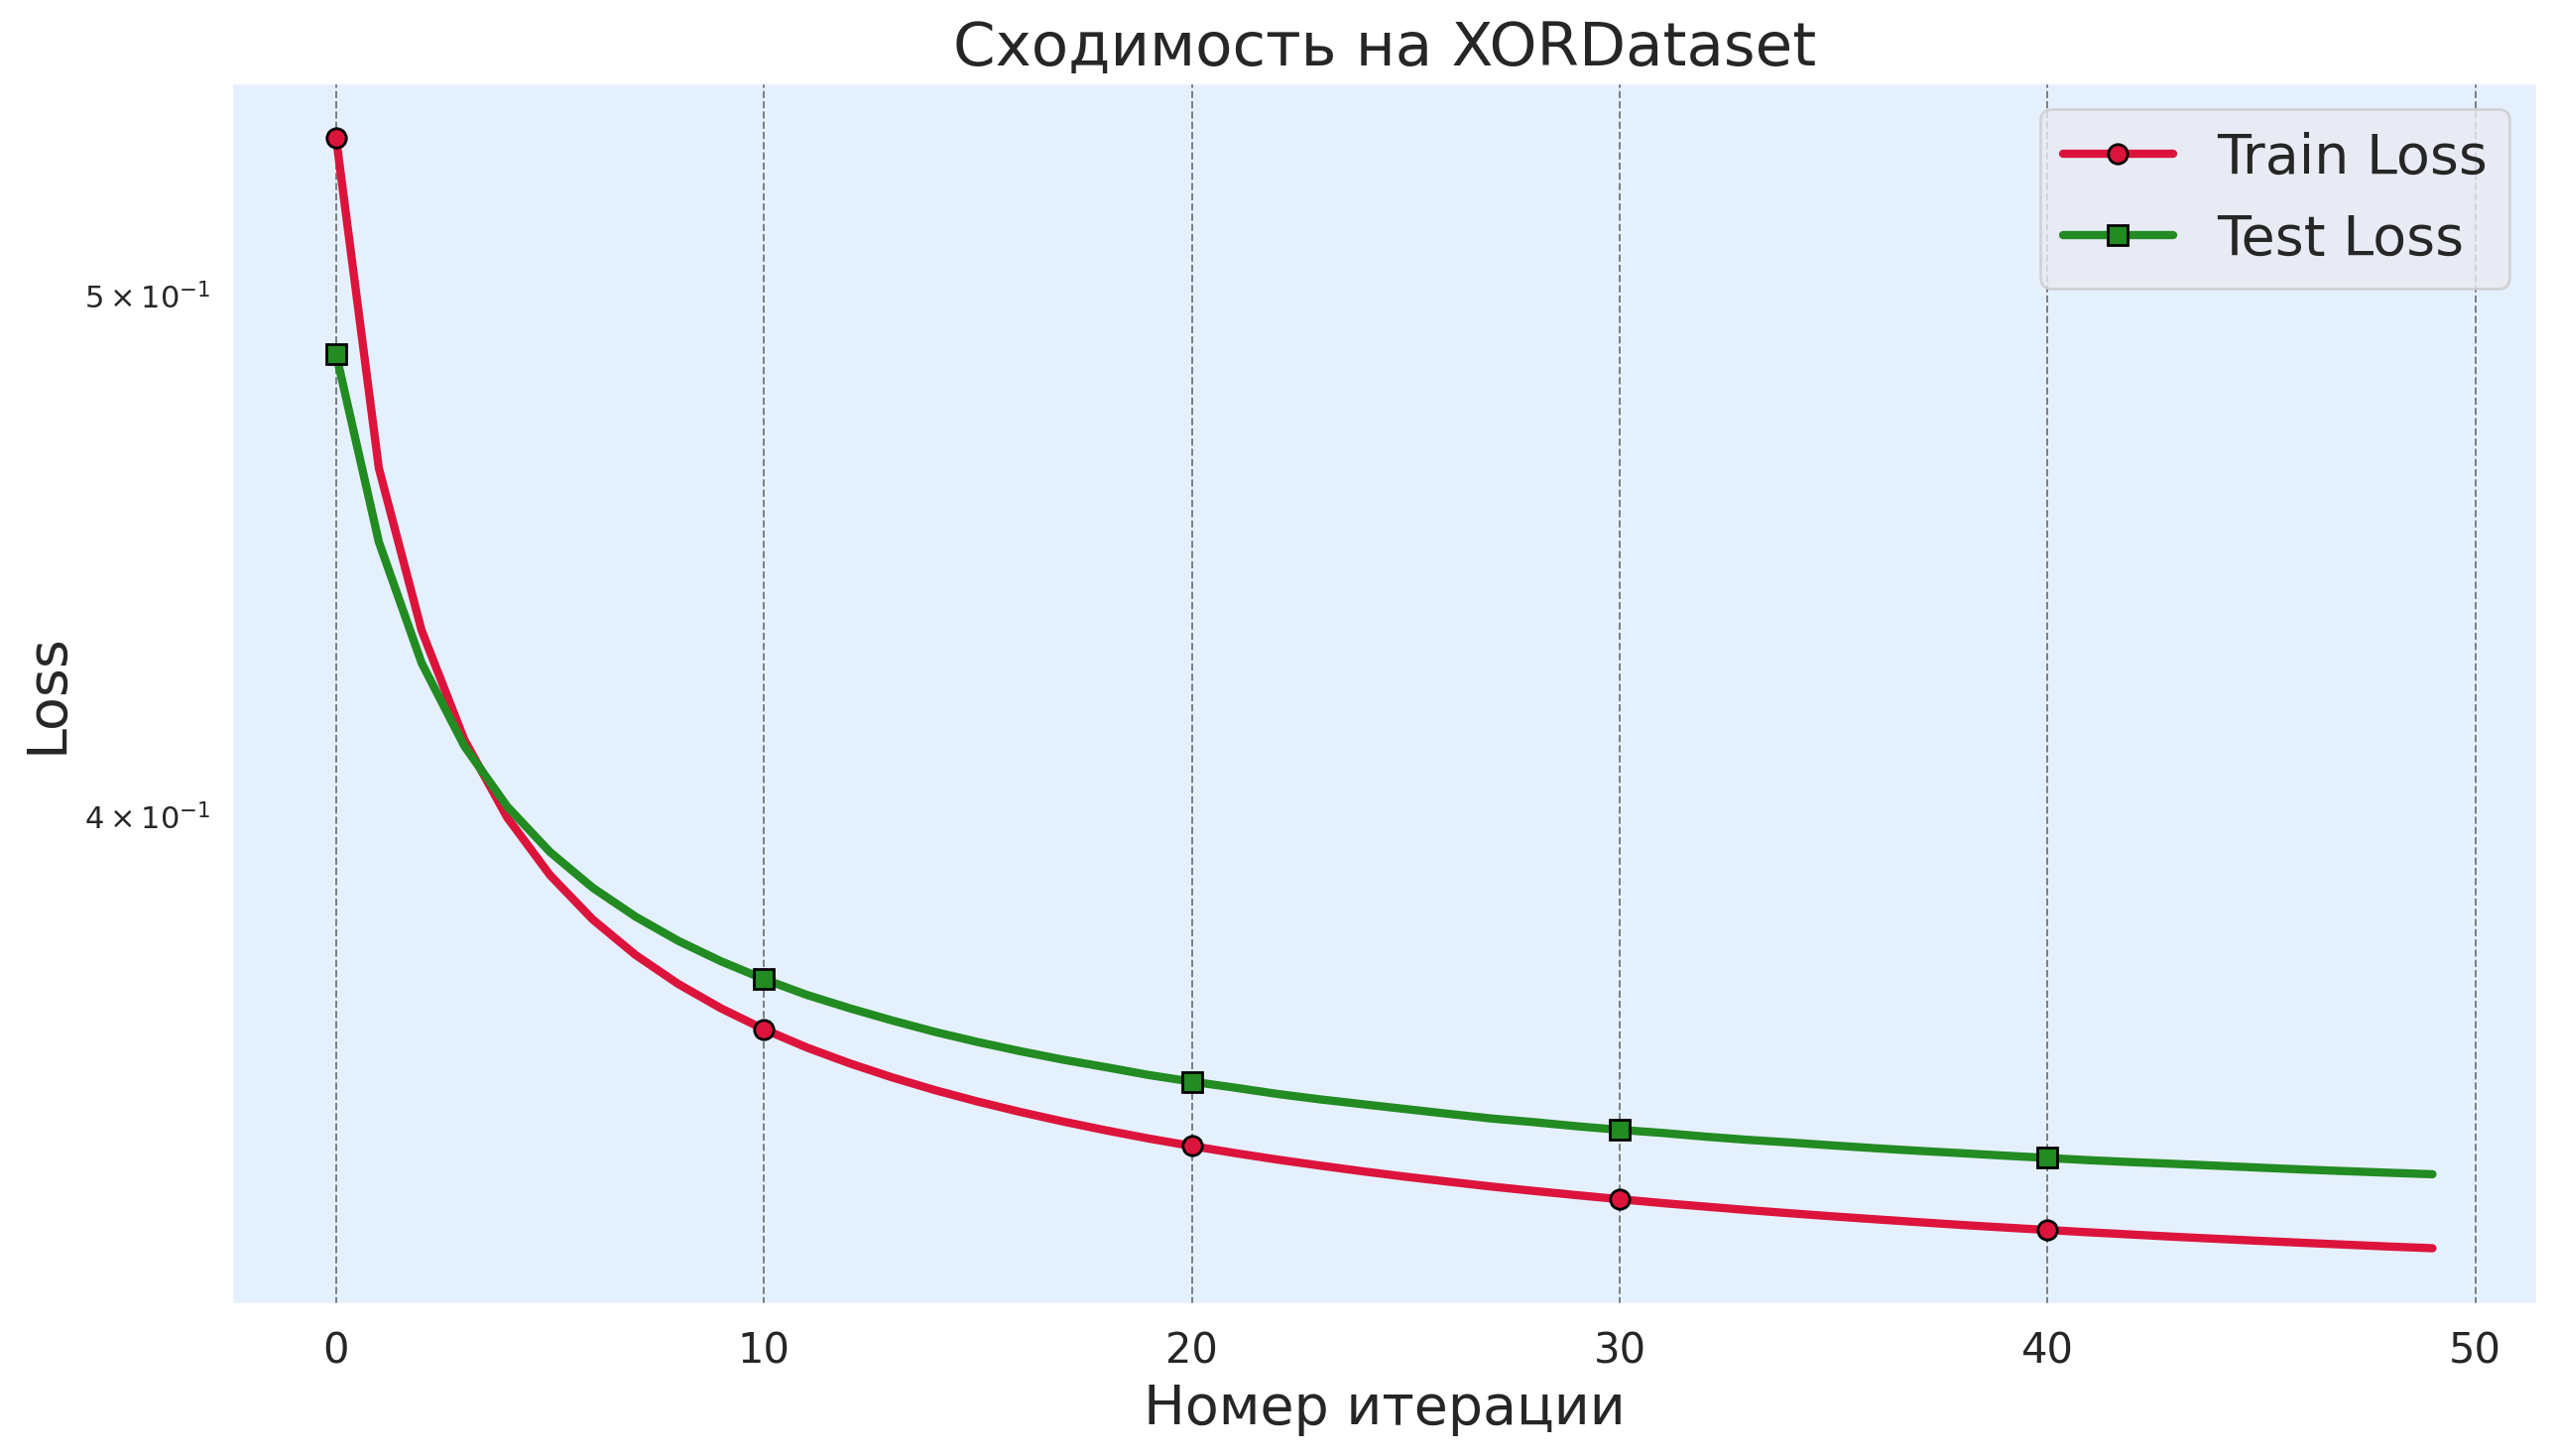

In [11]:
make_plots_loss([train_loss_dict, test_loss_dict], title='Сходимость на XORDataset')

__Задача 2.__ В предыдущей задаче мы убедились, что даже простая модель быстро достигает высокой точности на табличных данных — достаточно одной эпохи для получения высокого значения метрики. Однако в реальных задачах, данные сложнее, и выбор гиперпараметров играет важную роль. В этом задании мы посмотрим, как размер батча влияет на качество обучения и скорость сходимости модели на примере датасета [`FashionMNIST`](https://www.kaggle.com/datasets/zalando-research/fashionmnist).

In [12]:
class FashionMNIST(Dataset):
    def __init__(self, root='.', download=True):
        transform = transforms.Compose([
            transforms.ToTensor()
        ])

        self.train_dataset = torchvision.datasets.FashionMNIST(
            root=root, train=True, download=download, transform=transform)
        self.test_dataset = torchvision.datasets.FashionMNIST(
            root=root, train=False, download=download, transform=transform)

    def __getitem__(self, index):
        """
        Получение одного элемента из набора данных
        """
        return self.dataset.__getitem__(index)

    def __len__(self):
        """
        Количество элементов в наборе данных
        """
        return self.dataset.__len__()

In [13]:
FashionMNIST_dataset = FashionMNIST(root='.')

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.91MB/s]


In [14]:
fashion_classes = (
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
)

def imshow_fashionmnist(img, ax=None, title=None):
    npimg = img.numpy().squeeze()  # (1, H, W) → (H, W)
    if ax is None:
        plt.imshow(npimg, cmap='gray')
        if title:
            plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(npimg, cmap='gray')
        if title:
            ax.set_title(title)
        ax.axis('off')

def show_fashionmnist_samples(dataset, num_samples=20, rows=4, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for idx, ax in zip(indices, axes):
        image, label = dataset[idx]
        imshow_fashionmnist(image, ax=ax, title=fashion_classes[label])

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Amount of train samples: 60000
Amount of test samples: 10000


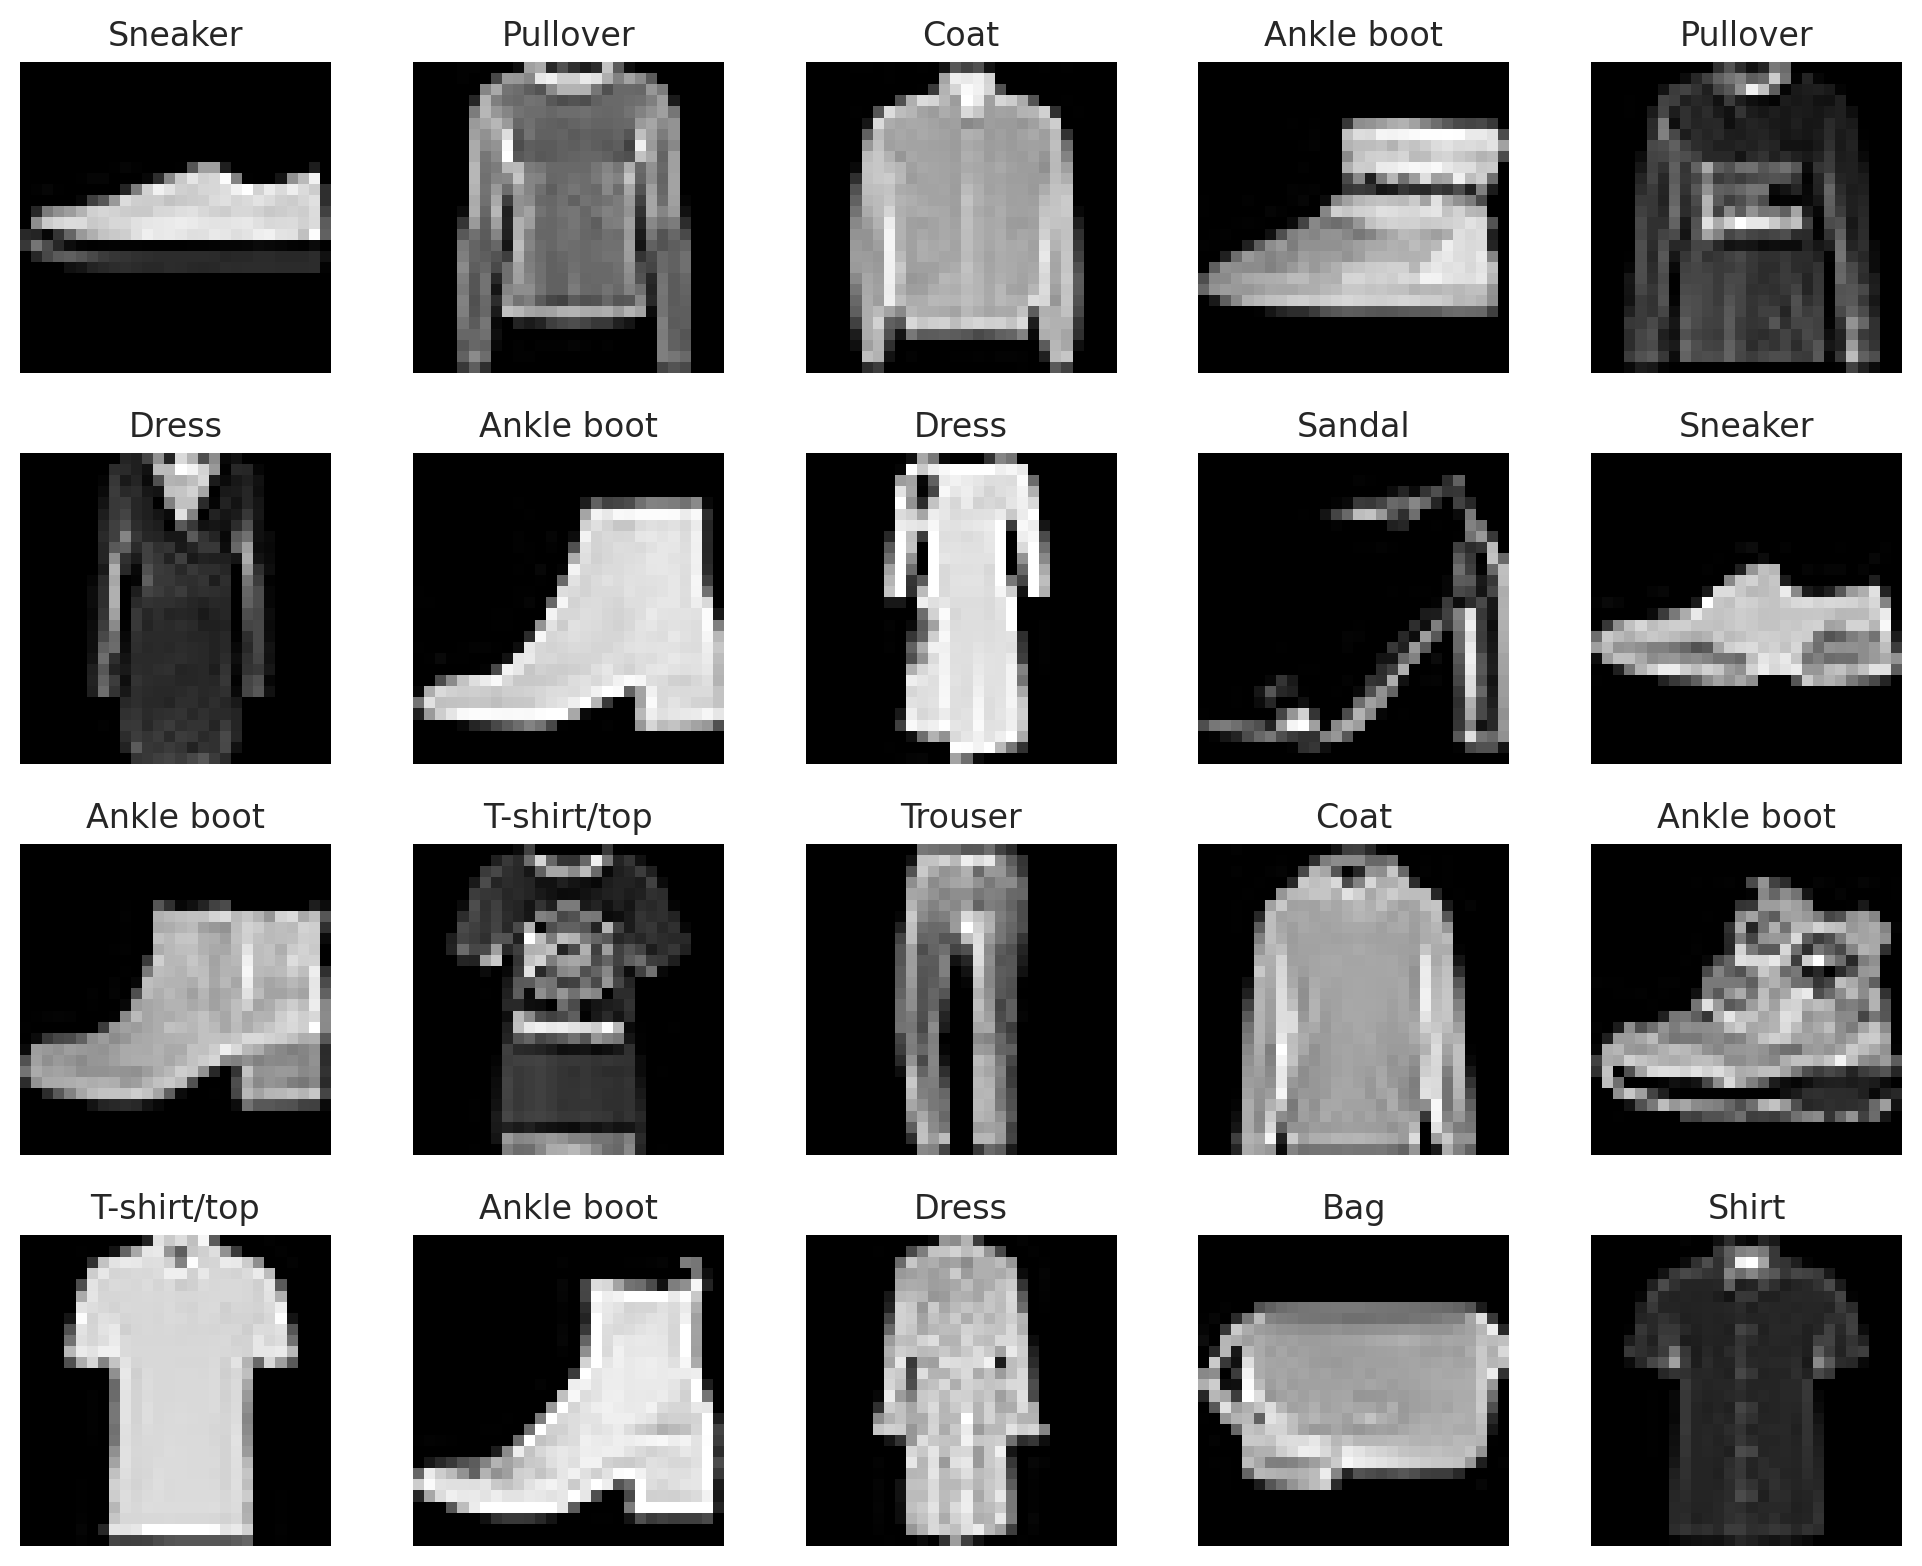

In [15]:
print(f"Amount of train samples: {len(FashionMNIST_dataset.train_dataset)}")
print(f"Amount of test samples: {len(FashionMNIST_dataset.test_dataset)}")

show_fashionmnist_samples(FashionMNIST_dataset.train_dataset)

__а) (1 балл)__ Рассмотрим более глубокую нейронную сеть, так как логистическая регрессия недостаточно хорошо приближает распределение данных в датасете F-MNIST. Реализуйте Multi-Layerd Perceptron (MLP), считая известным, что F-MNIST состоит из картинок размера 28*28, а число классов в нем равно 10:
1. [nn.Flatten()](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)
2. [nn.Linear(input_size, hidden_size)](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
3. [nn.Relu()](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
4. [nn.Linear(hidden_size, num_classes)](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

In [16]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=256, num_classes=10):
        super().__init__()
        self.Flatten = nn.Flatten()
        self.Linear1 = nn.Linear(input_size, hidden_size)
        self.ReLU = nn.ReLU()
        self.Linear2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output = self.Flatten(x)
        output = self.Linear1(output)
        output = self.ReLU(output)
        output = self.Linear2(output)
        return output


__б) (1 балл)__ Модифицируйте метод `trainer`, добавив поддержку многоклассовой классификации.

In [17]:
def trainer(num_epochs, batch_size, model_class, criterion, optimizer_class,
            optimizer_params, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):

    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        dataset (Dataset): Объект датасета
        device (str): Устройство для вычислений

    Возвращает:
        tuple: (train_losses, train_accuracies, test_losses, test_accuracies)
            train_losses: значения потерь на обучении
            train_accuracies: значения accuracy на обучении
            test_losses: значения потерь на тесте
            test_accuracies: значения accuracy на тесте
    """
    # Инициализация DataLoader
    train_loader = DataLoader(dataset.train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Инициализация модели
    model = model_class().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_params)

    # Метрики
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    # Функции для train/test одной эпохи
    def train_epoch(epoch):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            data = data.float()
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pred = torch.argmax(output, dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. *  (correct / total)
        return train_loss, train_acc

    def test_epoch(epoch):
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                data = data.float()
                output = model(data)
                loss = criterion(output, target)
                running_loss += loss.item()
                pred = torch.argmax(output, dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)
        test_loss = running_loss / len(test_loader.dataset)
        test_acc = 100. * (correct / total)
        return test_loss, test_acc


    # Основной цикл обучения
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Сохранение метрик
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        # Вывод статистики
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch + 1} / {num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | '
              f'Time: {epoch_time:.2f}s')

    return train_losses, train_accuracies, test_losses, test_accuracies

__в) (1 балл)__ Исследуйте влияние размера батча на качество модели. Используя предоставленный шаблон, постройте сравнительные графики значений функции потерь и значений метрики `accuracy` в зависимости от размера батча.

In [18]:
batch_sizes = [32, 64, 128, 256]

base_lr = 1e-3

train_acc_list=[]
test_acc_list=[]
train_loss_list=[]
test_loss_list=[]

for batch_size in batch_sizes:
    print(f"\n=== Training with batch size: {batch_size} ===")
    config = {
        'num_epochs': 10,
        'model_class': MLP,
        'criterion': nn.CrossEntropyLoss(reduction='sum'),
        'optimizer_class': SGD,
        'optimizer_params': {
            'lr': base_lr * np.sqrt(batch_size / 32),
            'momentum': 0.8,
            'weight_decay': 1e-4,
        },
        'dataset': FashionMNIST(),
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'batch_size': batch_size
    }

    train_loss, train_acc, test_loss, test_acc = trainer(**config)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)



=== Training with batch size: 32 ===
Epoch 1 / 10 | Train Loss: 0.6602 | Train Acc: 77.55% | Test Loss: 0.5508 | Test Acc: 80.33% | Time: 11.40s
Epoch 2 / 10 | Train Loss: 0.4595 | Train Acc: 83.88% | Test Loss: 0.4622 | Test Acc: 83.58% | Time: 11.30s
Epoch 3 / 10 | Train Loss: 0.4157 | Train Acc: 85.41% | Test Loss: 0.4241 | Test Acc: 85.11% | Time: 9.51s
Epoch 4 / 10 | Train Loss: 0.3872 | Train Acc: 86.32% | Test Loss: 0.4011 | Test Acc: 85.67% | Time: 9.49s
Epoch 5 / 10 | Train Loss: 0.3667 | Train Acc: 87.04% | Test Loss: 0.3940 | Test Acc: 85.81% | Time: 9.66s
Epoch 6 / 10 | Train Loss: 0.3499 | Train Acc: 87.64% | Test Loss: 0.3781 | Test Acc: 86.37% | Time: 10.10s
Epoch 7 / 10 | Train Loss: 0.3354 | Train Acc: 88.05% | Test Loss: 0.3860 | Test Acc: 86.39% | Time: 11.02s
Epoch 8 / 10 | Train Loss: 0.3260 | Train Acc: 88.25% | Test Loss: 0.3742 | Test Acc: 86.52% | Time: 9.69s
Epoch 9 / 10 | Train Loss: 0.3147 | Train Acc: 88.67% | Test Loss: 0.3764 | Test Acc: 86.49% | Time: 9

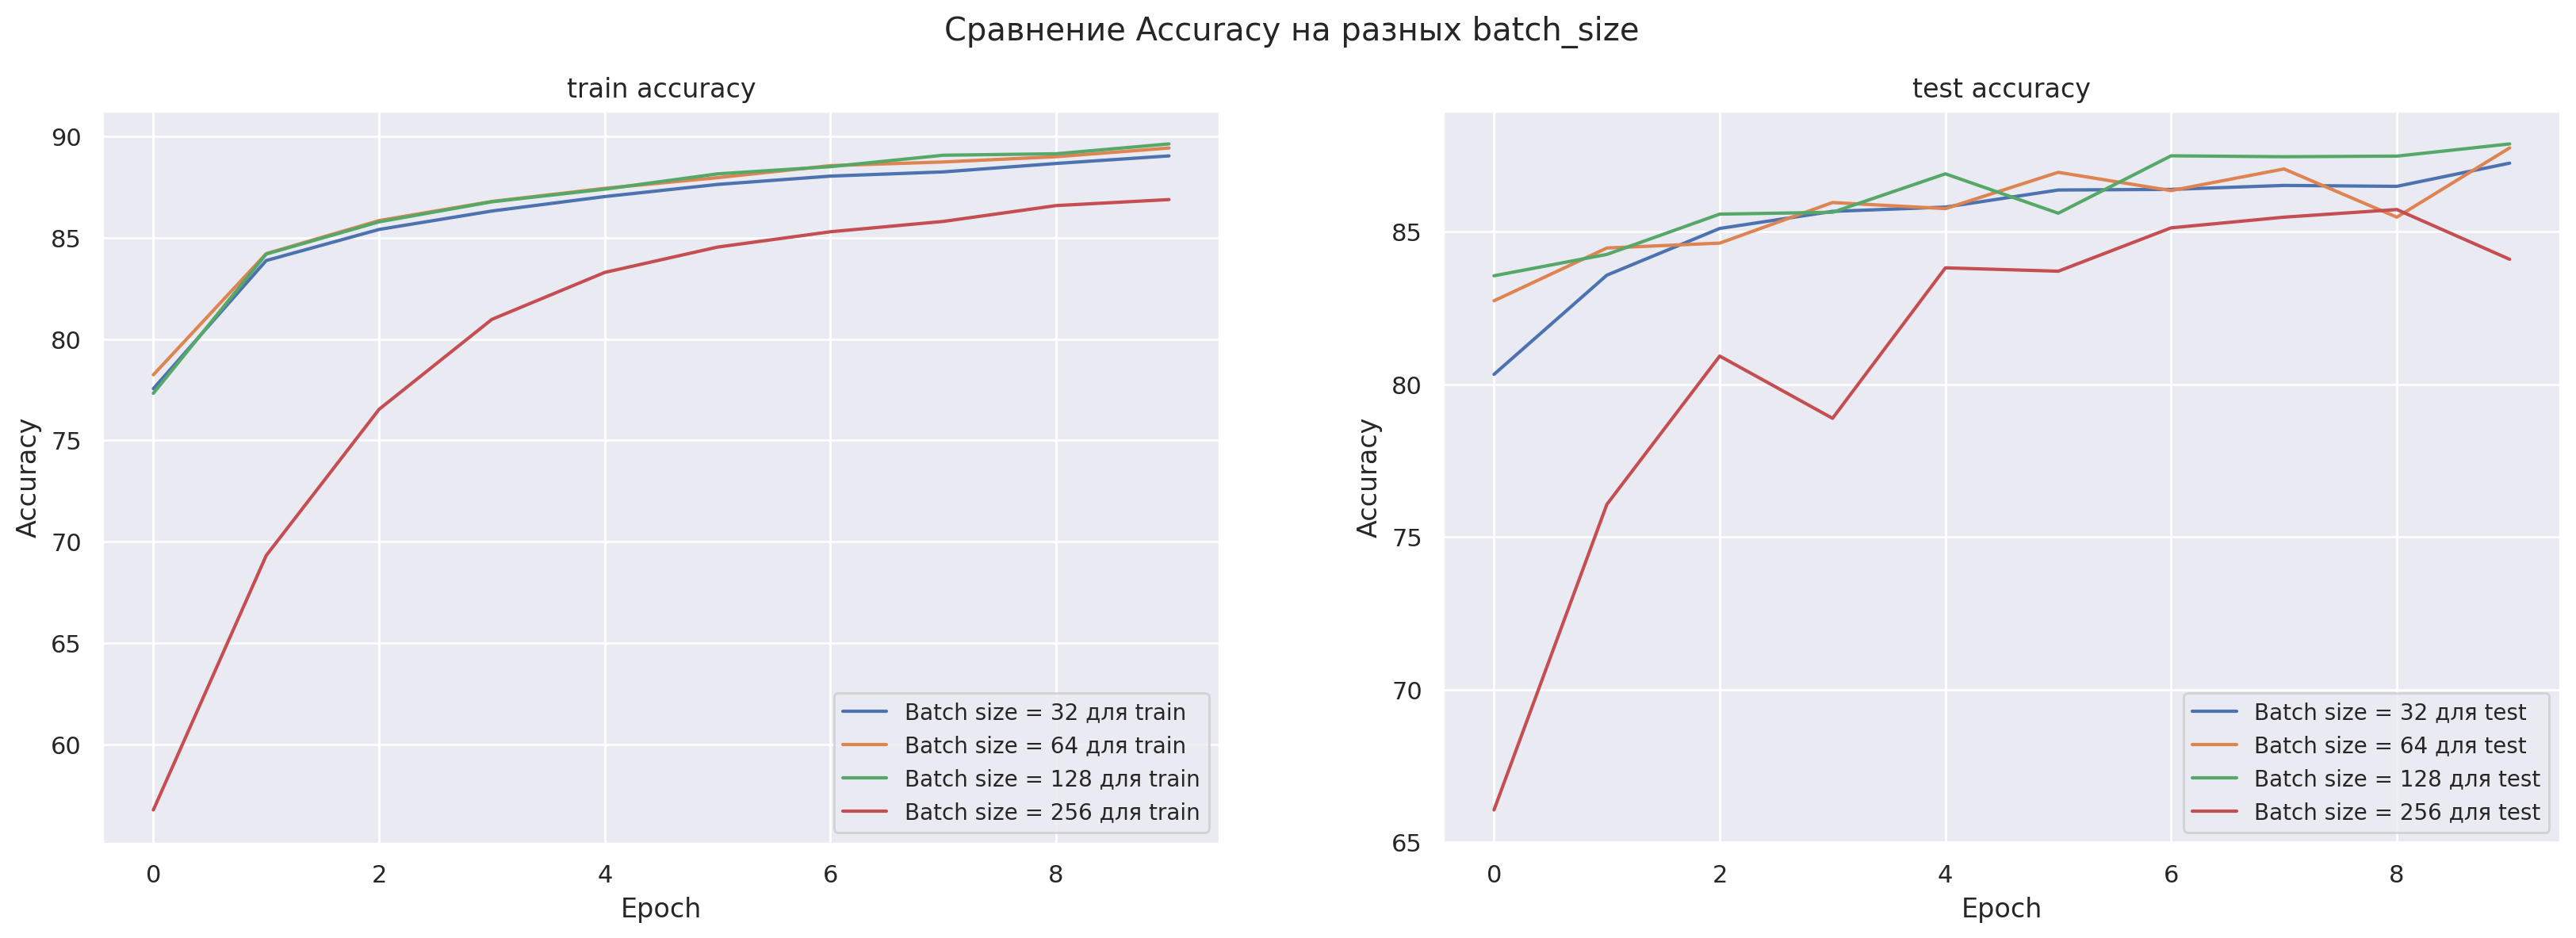

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
for i, batch_size in enumerate([32, 64, 128, 256]):
    ax[0].plot(np.arange(10), train_acc_list[i], label=f"Batch size = {batch_size} для train")
    ax[1].plot(np.arange(10), test_acc_list[i], label=f"Batch size = {batch_size} для test")

ax[0].set_title("train accuracy")
ax[0].set_xlabel('Epoch', fontsize=12)
ax[0].set_ylabel('Accuracy', fontsize=12)
ax[0].legend(fontsize=10)

ax[1].set_title("test accuracy")
ax[1].set_xlabel('Epoch', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].legend(fontsize=10)

fig.suptitle('Сравнение Accuracy на разных batch_size')
plt.show()



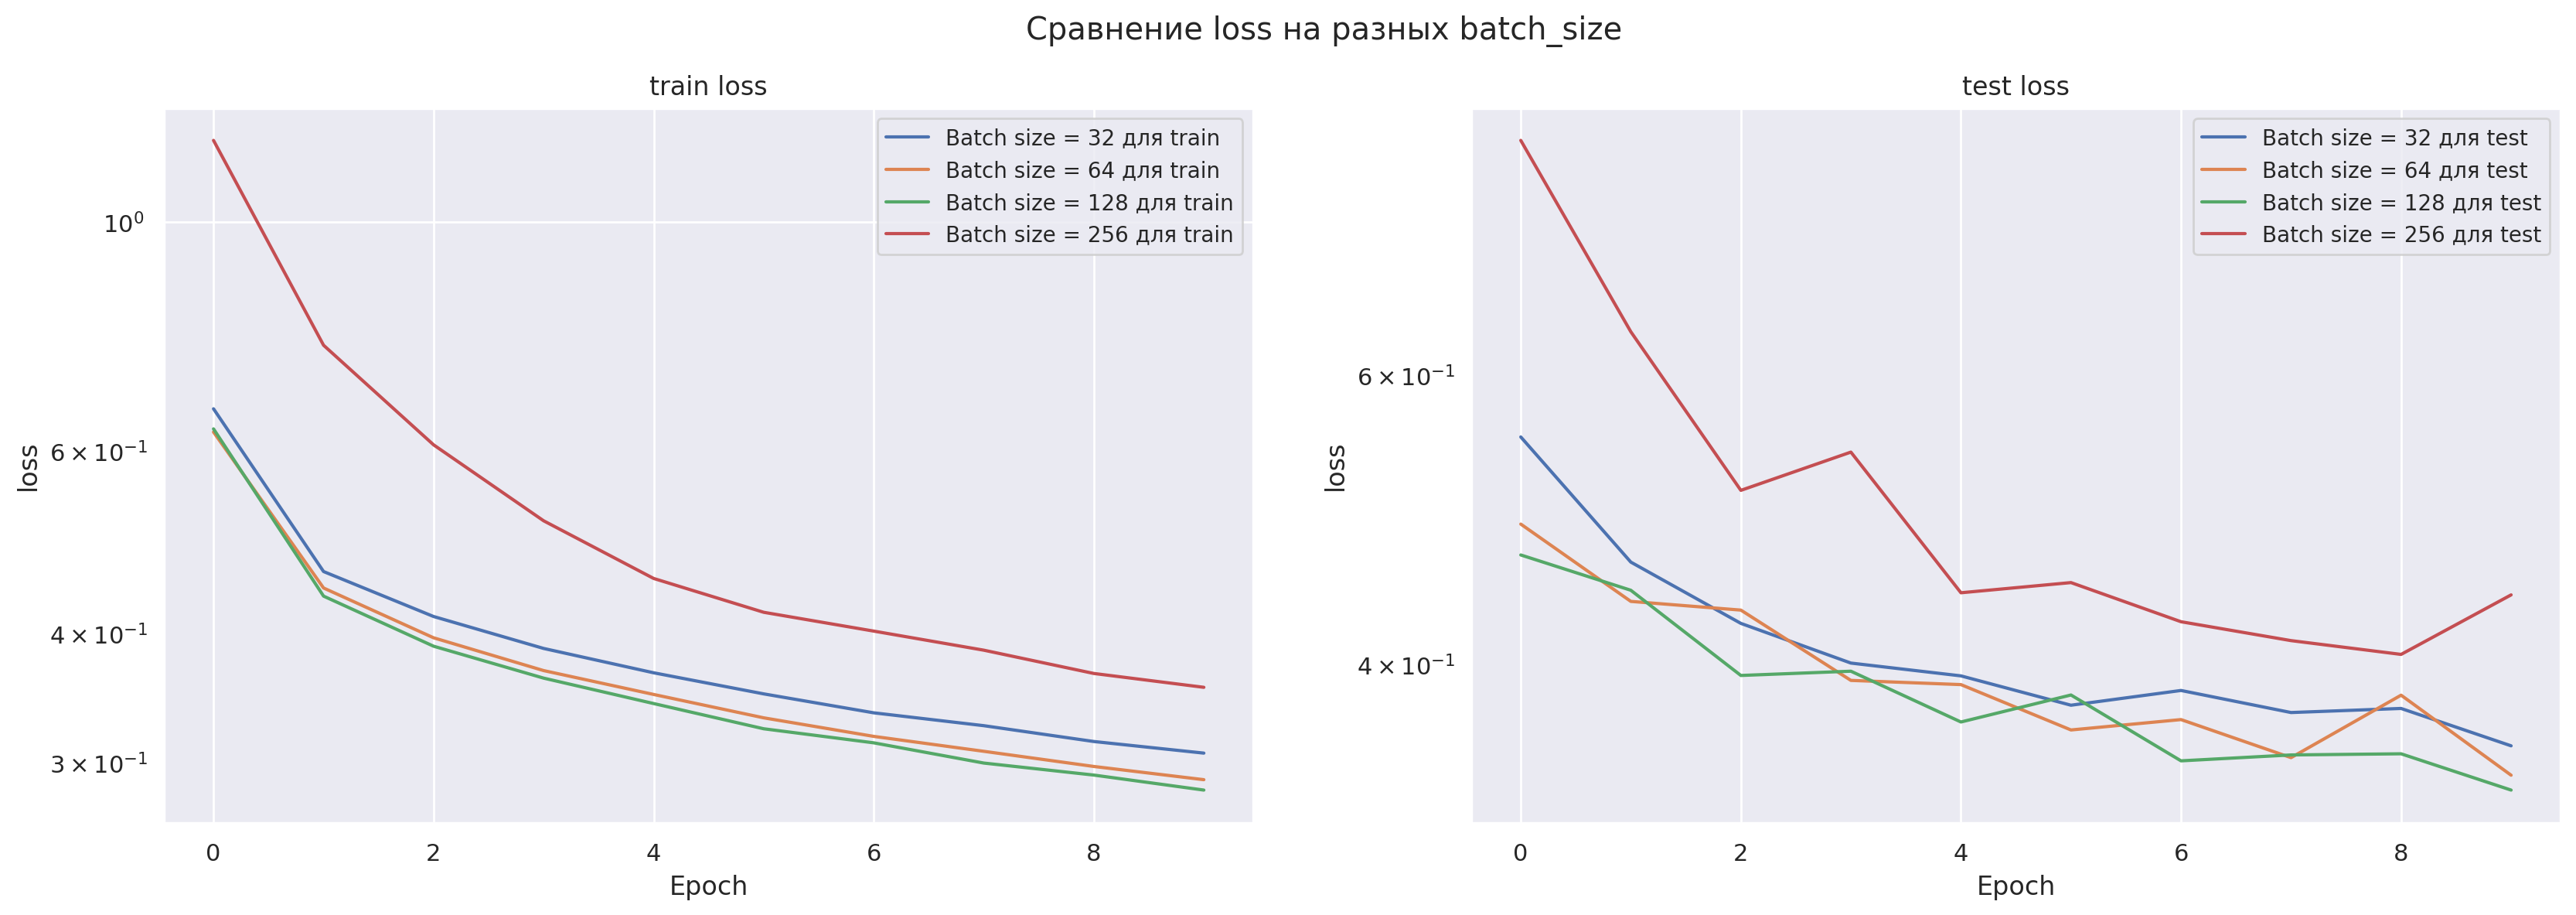

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
for i, batch_size in enumerate([32, 64, 128, 256]):
    ax[0].plot(np.arange(10), train_loss_list[i], label=f"Batch size = {batch_size} для train")
    ax[1].plot(np.arange(10), test_loss_list[i], label=f"Batch size = {batch_size} для test")

ax[0].set_title("train loss")
ax[0].set_xlabel('Epoch', fontsize=12)
ax[0].set_ylabel('loss', fontsize=12)
ax[0].legend(fontsize=10)
ax[0].set_yscale("log")

ax[1].set_title("test loss")
ax[1].set_xlabel('Epoch', fontsize=12)
ax[1].set_ylabel('loss', fontsize=12)
ax[1].legend(fontsize=10)
ax[1].set_yscale("log")

fig.suptitle('Сравнение loss на разных batch_size')
plt.show()

Батч из 128 элементов показывает лучшие результаты среди всех остальных, но 256 видно что слишком много

## Дополнительная часть (10 баллов)

In [21]:
import warnings
warnings.filterwarnings("ignore")

from torch import optim
from torchvision.models import resnet18

__Задача 2.__ В данной части будут рассмотрены не столь "игрушечные" датасеты, а уже проверенный временем бенчмарк для компьютерного зрения — связка из датасета [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) (картинки 32 $\times$ 32, 50,000 сэмплов train, 10,000 сэмплов test, 10 классов) и нейронной архитектуры [ResNet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html). Так как курс посвящен оптимизации, то предлагается импортировать саму архитектуру (без непосредственной реализации) и работать с ней в парадигме "black-box" оптимизации — дан черный ящик в виде модели, хотим достичь наилучшего качества обучения.

In [22]:
class CIFAR10(Dataset):
    def __init__(self, root, download=True, normalize_mean=(0.5, 0.5, 0.5), normalize_std=(0.5, 0.5, 0.5)):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(normalize_mean, normalize_std)
        ])

        self.train_dataset = torchvision.datasets.CIFAR10(
            root = '.',
            train = True,
            transform = transform,
            download = download,
        )
        self.test_dataset = torchvision.datasets.CIFAR10(
            root = '.',
            train = False,
            transform = transform,
            download = download,
        )

    def __getitem__(self, index):
        """
        Получение одного элемента из набора данных
        """
        return self.dataset.__getitem__(index)

    def __len__(self):
        """
        Количество элементов в наборе данных
        """
        return self.dataset.__len__()

In [23]:
CIFAR10_dataset = CIFAR10(root='.')

100%|██████████| 170M/170M [00:30<00:00, 5.56MB/s]


In [24]:
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img, ax=None, title=None):
    img = img / 2 + 0.5
    npimg = img.numpy()
    if ax is None:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        if title:
            plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(np.transpose(npimg, (1, 2, 0)))
        if title:
            ax.set_title(title)
        ax.axis('off')


def show_dataset_samples(dataset, num_samples=20, rows=4, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for i, ax in enumerate(zip(indices, axes)):
        image, label = dataset[i]
        imshow(image, ax=ax[1], title=classes[label])

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Amount of train samples: 50000
Amount of test samples: 10000


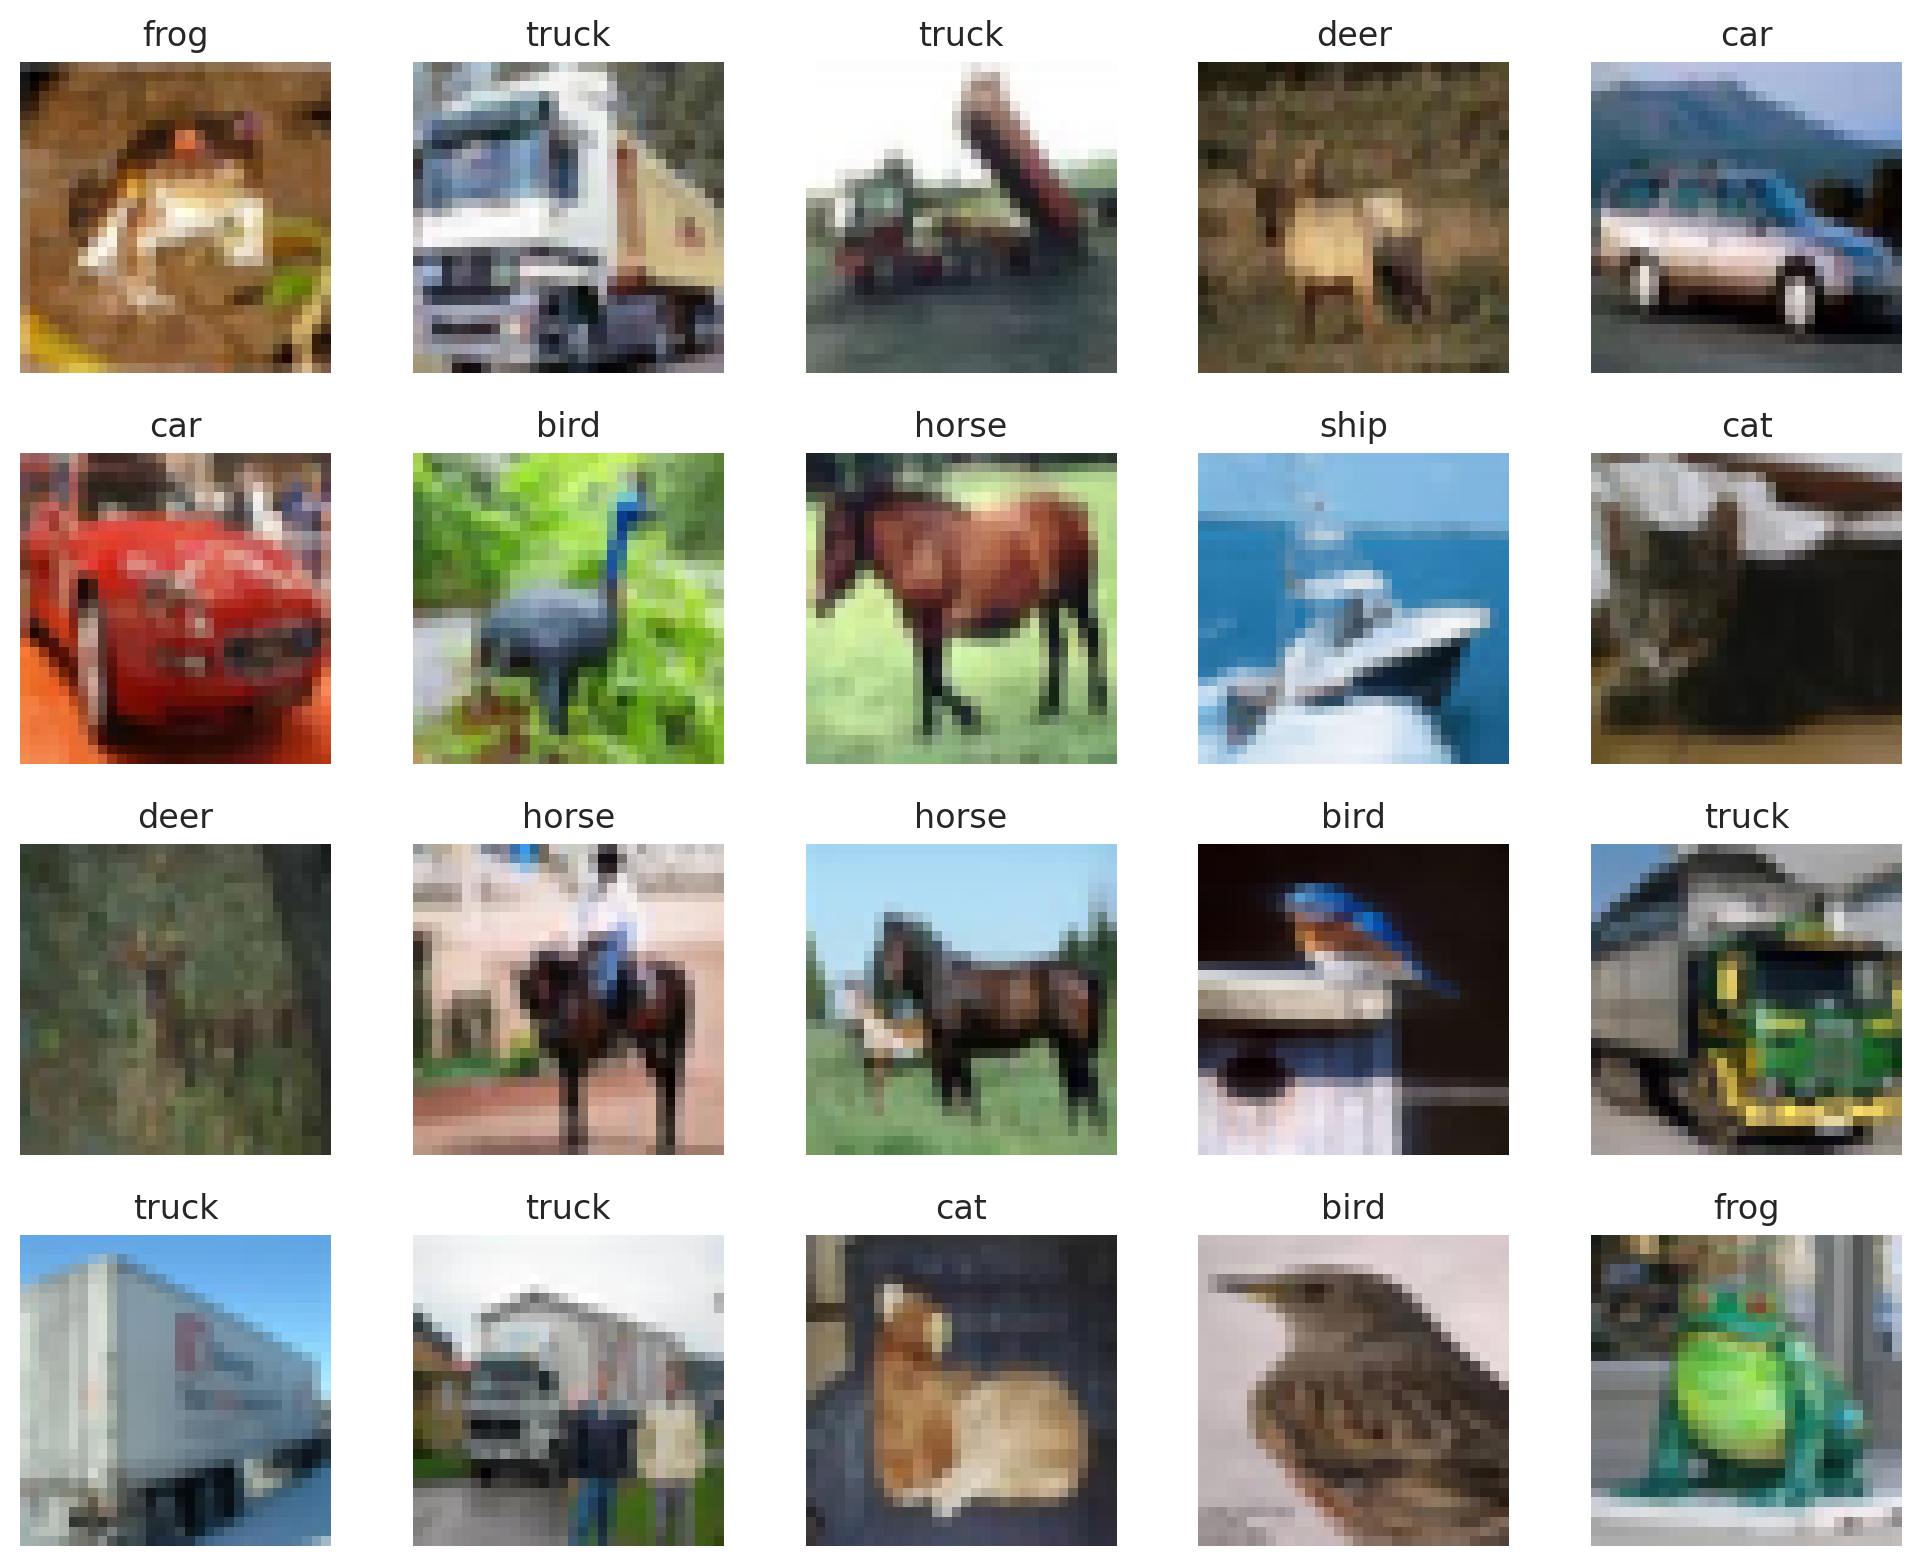

In [25]:
print(f"Amount of train samples: {len(CIFAR10_dataset.train_dataset)}")
print(f"Amount of test samples: {len(CIFAR10_dataset.test_dataset)}")

show_dataset_samples(CIFAR10_dataset.train_dataset)

Теперь проинициализируем сверточную модель `ResNet18` ([оригинальная статья](https://arxiv.org/abs/1512.03385), [реализация в torch](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)), для желающих разобраться, из каких слоев она состоит, добавлена функция `print_model_summary`, в которой перечислены все слои и число обучаемых параметров.

In [26]:
# Число классов в датасете - 10
resnet = resnet18(weights=None, num_classes=10)

In [27]:
def print_model_summary(model, input_size):
    def register_hook(module):
        def hook(module, input, output):
            class_name = str(module.__class__).split(".")[-1].split("'")[0]
            module_idx = len(summary)

            m_key = f"{class_name}-{module_idx+1}"
            summary[m_key] = {
                "input_shape": list(input[0].size()),
                "output_shape": list(output.size()),
                "nb_params": sum(p.numel() for p in module.parameters())
            }

        if not isinstance(module, nn.Sequential) and not isinstance(module, nn.ModuleList) and module != model:
            hooks.append(module.register_forward_hook(hook))

    summary = {}
    hooks = []

    model.apply(register_hook)

    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, *input_size))

    for h in hooks:
        h.remove()

    print("----------------------------------------------------------------")

    line_new = "{:>20}  {:>25} {:>15}".format("Layer (type)", "Output Shape", "Param #")
    print(line_new)
    print("================================================================")

    total_params = 0

    for layer in summary:
        line_new = "{:>20}  {:>25} {:>15}".format(
            layer,
            str(summary[layer]["output_shape"]),
            "{0:,}".format(summary[layer]["nb_params"])
        )

        total_params += summary[layer]["nb_params"]

        print(line_new)

    print("================================================================")
    print(f"Total params: {total_params:,}")
    print("----------------------------------------------------------------")

# Входной размер картинки - (3, 32, 32), так как она RGB-шная
print_model_summary(resnet, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [1, 64, 16, 16]           9,408
       BatchNorm2d-2            [1, 64, 16, 16]             128
              ReLU-3            [1, 64, 16, 16]               0
         MaxPool2d-4              [1, 64, 8, 8]               0
            Conv2d-5              [1, 64, 8, 8]          36,864
       BatchNorm2d-6              [1, 64, 8, 8]             128
              ReLU-7              [1, 64, 8, 8]               0
            Conv2d-8              [1, 64, 8, 8]          36,864
       BatchNorm2d-9              [1, 64, 8, 8]             128
             ReLU-10              [1, 64, 8, 8]               0
       BasicBlock-11              [1, 64, 8, 8]          73,984
           Conv2d-12              [1, 64, 8, 8]          36,864
      BatchNorm2d-13              [1, 64, 8, 8]             128
             ReLU-14              [1, 6

__a) (5 баллов)__ Рассмотрите несколько типов `lr_scheduler` — планировщика скорости обучения, предоставлямых библиотекой `torch`:

1) [`LambdaLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LambdaLR.html)

$$
lr_{epoch + 1} = lr_{base} \cdot \lambda(epoch + 1)
$$

2) [`ExponentialLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html)

$$
lr_{epoch + 1} = \gamma \cdot lr_{epoch}
$$

3) [`ReduceLRonPlateu`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)

    Шаг уменьшается на фактор при достижении плато в функции ошибок.

4) [`CosineAnnealingLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html)

$$
lr_{epoch + 1} = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})
    \left(1 + \cos \left(\frac{\pi (epoch + 1)}{T_{\max}}\right)\right)
$$

5) [`LinearLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html)

$$
lr_{epoch + 1} = lr_{base} \cdot \left(\alpha + \left(1 - \alpha \right) \left(1 - \frac{epoch + 1}{T_{\max}}\right) \right)
$$

Для удобства дальнейшего использования предлагается функция `get_lr_schedule`.

In [28]:
def get_lr_schedule(model_class, optimizer_class, optimizer_params, scheduler_class, scheduler_params,
                    num_epochs=100, dummy_loss=None):
    """
    Возвращает список значений learning rate для заданного планировщика.

    Параметры:
        model_class (nn.Module): Модель
        optimizer_class (optim.Optimizer): Оптимизатор
        optimizer_params (dict): Параметры оптимизатора
        scheduler_class (optim.lr_scheduler): Планировщик скорости обучения
        scheduler_params (dict): Параметры планировщика
        num_epochs (int): Количество эпох для симуляции
        dummy_loss (list or None): Список значений потерь для ReduceLROnPlateau

    Возвращает:
        lrs (list): Список learning rate на каждой итерации
    """

    model = model_class()
    optimizer = optimizer_class(model.parameters(), **optimizer_params)
    scheduler = scheduler_class(optimizer, **scheduler_params)

    lrs = []

    for i in range(num_epochs):
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            loss = dummy_loss[i] if dummy_loss is not None else 1.0
            scheduler.step(loss)
        else:
            scheduler.step()

        lrs.append(optimizer.param_groups[0]['lr'])

    return lrs

Изобразите поведение от номера эпохи `lr_scheduler`: `ExponentialLR`, `ReduceLRonPlateu`, `CosineAnnealingLR`, `LinearLR` (используйте готовые реализации в `torch`).

In [29]:
# Простая модель
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 2)

    def forward(self, x):
        return self.linear(x)

In [30]:
num_epochs = 100
dummy_losses = [1.0 / (i + 1) for i in range(num_epochs - 30)] + [0.0001 for j in range(30)]

ol = optim.lr_scheduler
lr_exponential = get_lr_schedule(model_class=DummyModel,
                                 optimizer_class=SGD,
                                 optimizer_params={'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-6},
                                 scheduler_class=ol.ExponentialLR,
                                 scheduler_params={'gamma': 0.75},
                                 num_epochs=num_epochs)

lr_plateau = get_lr_schedule(model_class=DummyModel,
                                 optimizer_class=SGD,
                                 optimizer_params={'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-6},
                                 scheduler_class=ol.ReduceLROnPlateau,
                                 scheduler_params={'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 1e-3},
                                 num_epochs=num_epochs)

lr_cosine = get_lr_schedule(model_class=DummyModel,
                                 optimizer_class=SGD,
                                 optimizer_params={'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-6},
                                 scheduler_class=ol.CosineAnnealingLR,
                                 scheduler_params={'T_max': num_epochs},
                                 num_epochs=num_epochs)

lr_linear = get_lr_schedule(model_class=DummyModel,
                                 optimizer_class=SGD,
                                 optimizer_params={'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-6},
                                 scheduler_class=ol.LinearLR,
                                 scheduler_params={'start_factor': 1.0, 'end_factor': 0.1, 'total_iters': num_epochs},
                                 num_epochs=num_epochs)

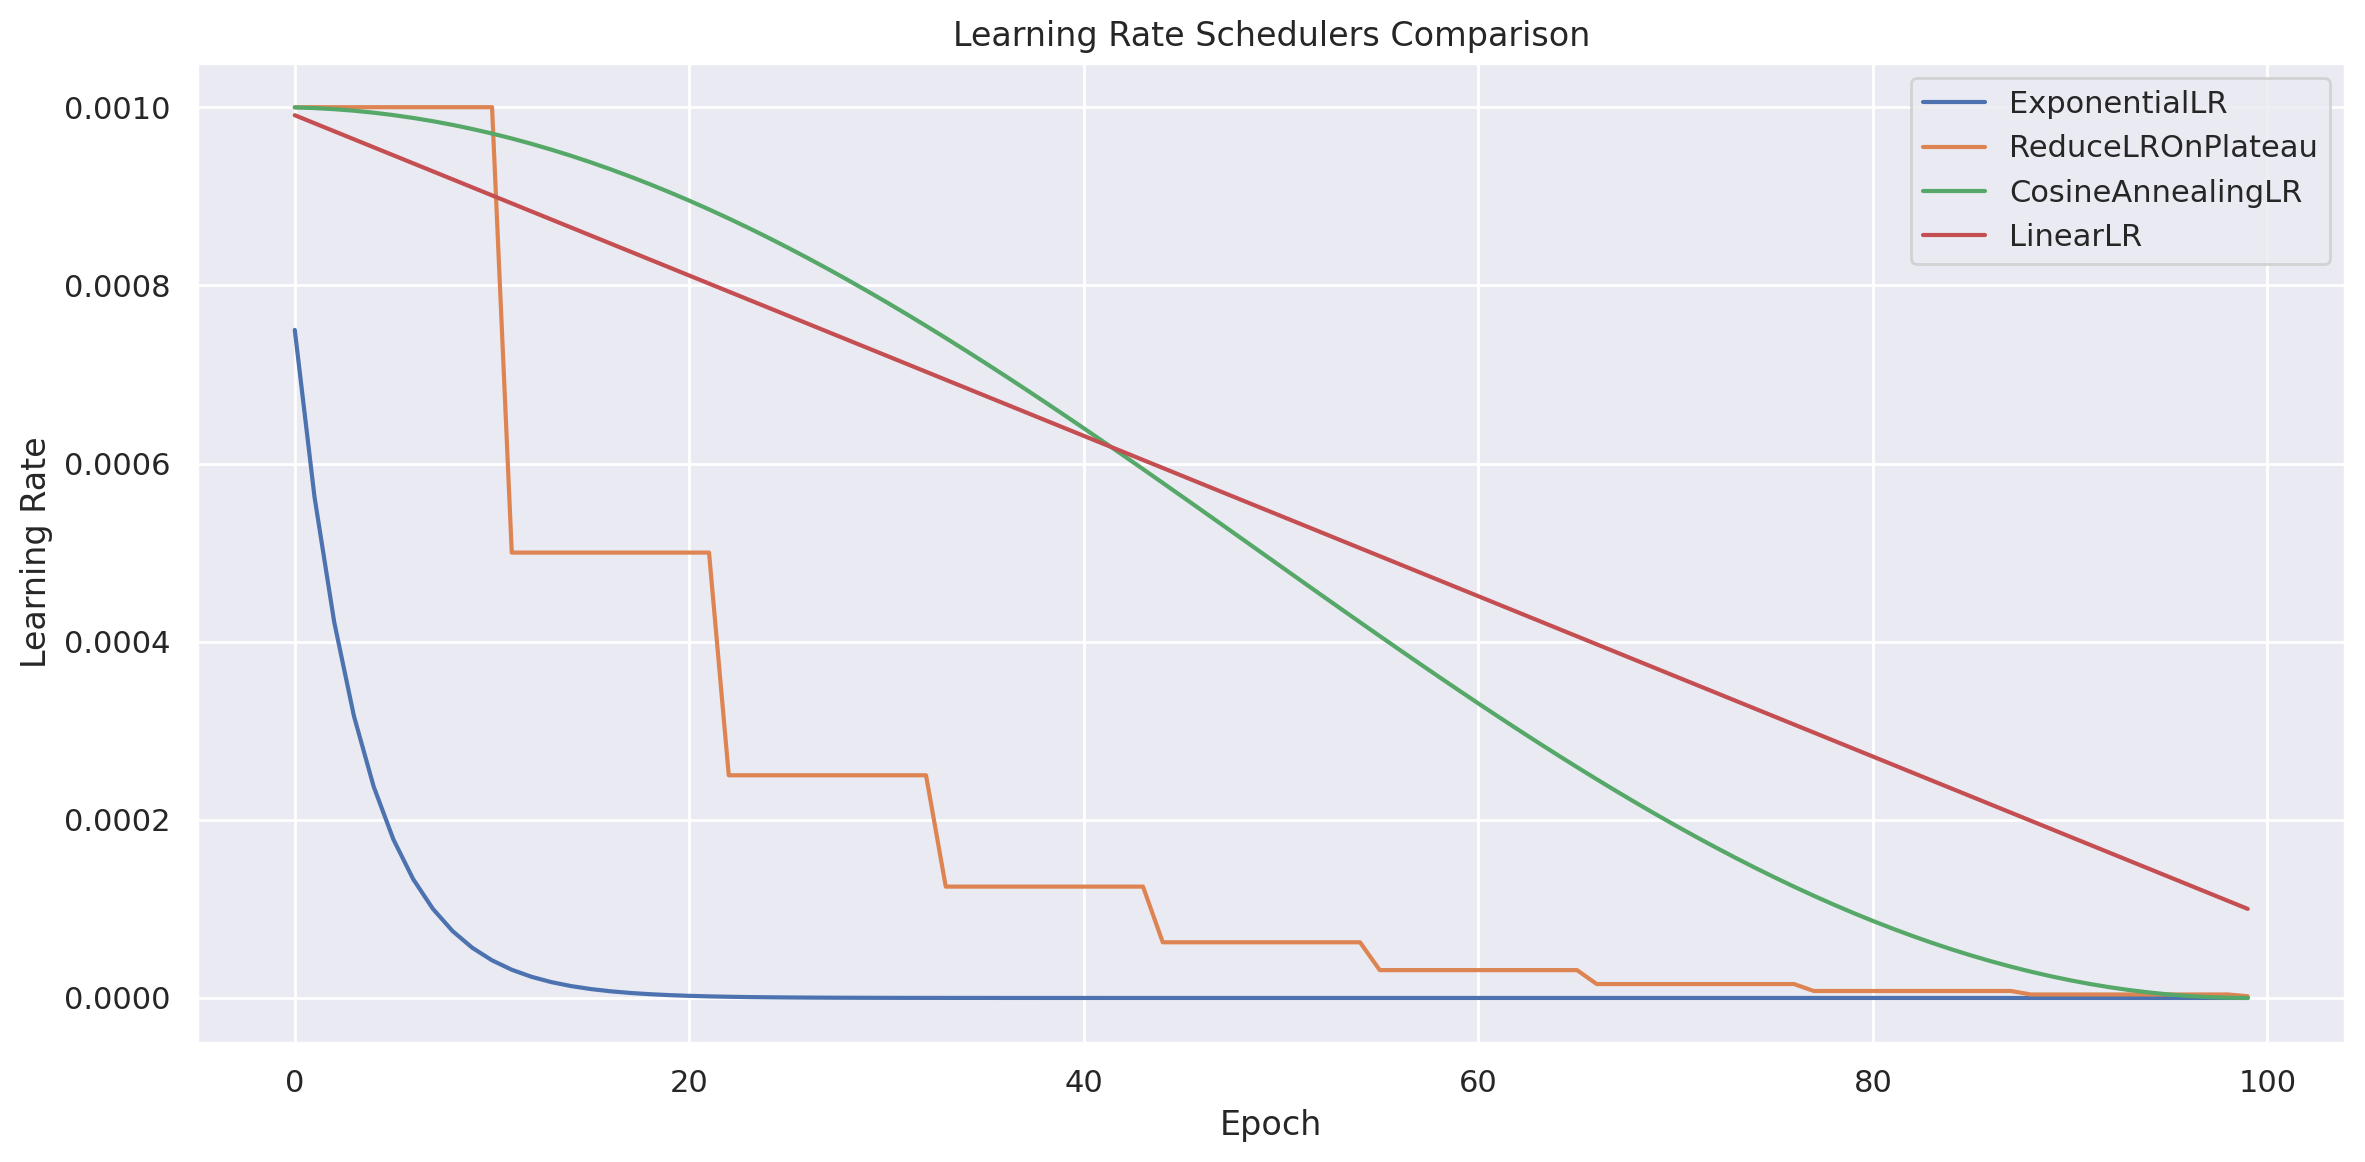

In [31]:
# Визуализация

plt.figure(figsize=(12, 6))
plt.plot(lr_exponential, label="ExponentialLR")
plt.plot(lr_plateau, label="ReduceLROnPlateau")
plt.plot(lr_cosine, label="CosineAnnealingLR")
plt.plot(lr_linear, label="LinearLR")

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedulers Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Теперь применим соответсвующие скедулеры для связки `CIFAR10` + `ResNet18`. Дополните функцию `trainer` с обновлением шага раз в эпоху. Добавьте возможность использования скедулера/шедулера (`torch.optim.lr_scheduler`), а также убрав значения входных размерностей, так как они известны. В качестве оптимизатора используйте написанный класс `SGD` с параметром моментума равным 0.8. Постройте сравнительные графики функции ошибок и значений метрики для каждого скедулера. Какой скедулер показал себя лучше всего?

In [32]:
def trainer(num_epochs, batch_size, model_class, criterion, optimizer_class=SGD, optimizer_params=None,
            scheduler_class=None, scheduler_params=None, dataset=None,
            device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        scheduler_class (optim.lr_scheduler): Класс планировщика скорости обучения
        scheduler_params (dict): Параметры планировщика скорости обучения
        dataset (Dataset): Объект датасета
        device (str): Устройство для вычислений

    Возвращает:
        model (nn.Module): Обученная модель
        metrics (dict): Словарь с логами
    """

    # Создаем загрузчики данных
    train_loader = DataLoader(dataset.train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Инициализируем модель, оптимизатор
    model = model_class.to(device)
    optimizer = optimizer_class(model.parameters(), **(optimizer_params or {}))

    # Инициализируем планировщик
    scheduler = None
    if scheduler_class is not None:
        scheduler = scheduler_class(optimizer, **(scheduler_params or {}))

    # Метрики
    metrics = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "learning_rates": []
    }

    def train_epoch(epoch):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            data = data.float()
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pred = torch.argmax(output, dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. *  (correct / total)
        return train_loss, train_acc

    def test_epoch(epoch):
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                data = data.float()
                output = model(data)
                loss = criterion(output, target)
                running_loss += loss.item()
                pred = torch.argmax(output, dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)
        test_loss = running_loss / len(test_loader.dataset)
        test_acc = 100. * (correct / total)
        return test_loss, test_acc

    # Обучение
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Шаг планировщика

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()

        # Сохраняем метрики
        metrics["train_loss"].append(train_loss)
        metrics["train_acc"].append(train_acc)
        metrics["test_loss"].append(test_loss)
        metrics["test_acc"].append(test_acc)
        metrics["learning_rates"].append(optimizer.param_groups[0]['lr'])

        # Логирование
        elapsed = time.time() - start_time
        print(f"Epoch {epoch + 1} / {num_epochs} | "
              f"LR: {metrics['learning_rates'][-1]:.2e} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"Time: {elapsed:.2f}s")

    # Возвращаем модель и метрики
    return model, metrics

Посмотрим на работу одного `lr_scheduler`. Используйте его как пример в построении графиков.

In [33]:
resnet = resnet18(weights=None, num_classes=10)

config = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'scheduler_class': optim.lr_scheduler.CosineAnnealingLR,
    'scheduler_params': {'T_max': 10, 'eta_min': 0.001},
    'dataset': CIFAR10_dataset,
    'device' : 'cuda',
}

# Запуск обучения
trained_resnet, metrics = trainer(**config)

Epoch 1 / 10 | LR: 9.78e-03 | Train Loss: 0.0129, Train Acc: 39.95% | Test Loss: 0.0113, Test Acc: 47.97% | Time: 30.08s
Epoch 2 / 10 | LR: 9.14e-03 | Train Loss: 0.0102, Train Acc: 52.94% | Test Loss: 0.0103, Test Acc: 53.22% | Time: 29.24s
Epoch 3 / 10 | LR: 8.15e-03 | Train Loss: 0.0088, Train Acc: 60.02% | Test Loss: 0.0097, Test Acc: 55.91% | Time: 28.66s
Epoch 4 / 10 | LR: 6.89e-03 | Train Loss: 0.0075, Train Acc: 66.11% | Test Loss: 0.0095, Test Acc: 58.33% | Time: 29.53s
Epoch 5 / 10 | LR: 5.50e-03 | Train Loss: 0.0062, Train Acc: 72.00% | Test Loss: 0.0093, Test Acc: 59.75% | Time: 28.88s
Epoch 6 / 10 | LR: 4.11e-03 | Train Loss: 0.0050, Train Acc: 78.05% | Test Loss: 0.0098, Test Acc: 59.42% | Time: 29.37s
Epoch 7 / 10 | LR: 2.85e-03 | Train Loss: 0.0038, Train Acc: 83.98% | Test Loss: 0.0101, Test Acc: 59.24% | Time: 29.07s
Epoch 8 / 10 | LR: 1.86e-03 | Train Loss: 0.0029, Train Acc: 89.02% | Test Loss: 0.0103, Test Acc: 60.16% | Time: 29.50s
Epoch 9 / 10 | LR: 1.22e-03 | Tr

Используя следующие параметры, постройте сравнительные графики функции ошибок и значений метрики для каждого `lr_scheduler`.

In [65]:
resnet = resnet18(weights=None, num_classes=10)

schedulers = {
    'CosineAnnealingLR': (optim.lr_scheduler.CosineAnnealingLR, {'T_max': 10, 'eta_min': 0.001}),
    'ExponentialLR': (optim.lr_scheduler.ExponentialLR, {'gamma': 0.9}),
    'ReduceLROnPlateau': (optim.lr_scheduler.ReduceLROnPlateau, {'mode': 'min', 'factor': 0.5, 'patience': 2}),
    'LinearLR': (optim.lr_scheduler.LinearLR, {'start_factor': 0.1, 'end_factor': 1.0, 'total_iters': 10}),
}

schedulers_list = {}

for scheduler_name, (scheduler_class, scheduler_params) in schedulers.items():
    config = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'scheduler_class': scheduler_class,
    'scheduler_params': scheduler_params,
    'dataset': CIFAR10_dataset,
    'device' : 'cuda',
    }

    # Запуск обучения
    schedulers_list[scheduler_name] = trainer(**config)



Epoch 1 / 10 | LR: 9.78e-03 | Train Loss: 0.0129, Train Acc: 40.05% | Test Loss: 0.0111, Test Acc: 48.76% | Time: 29.92s
Epoch 2 / 10 | LR: 9.14e-03 | Train Loss: 0.0101, Train Acc: 53.71% | Test Loss: 0.0100, Test Acc: 54.40% | Time: 29.26s
Epoch 3 / 10 | LR: 8.15e-03 | Train Loss: 0.0085, Train Acc: 61.02% | Test Loss: 0.0096, Test Acc: 56.88% | Time: 29.41s
Epoch 4 / 10 | LR: 6.89e-03 | Train Loss: 0.0073, Train Acc: 66.97% | Test Loss: 0.0093, Test Acc: 58.59% | Time: 29.04s
Epoch 5 / 10 | LR: 5.50e-03 | Train Loss: 0.0060, Train Acc: 73.12% | Test Loss: 0.0091, Test Acc: 60.00% | Time: 29.22s
Epoch 6 / 10 | LR: 4.11e-03 | Train Loss: 0.0048, Train Acc: 78.97% | Test Loss: 0.0095, Test Acc: 59.79% | Time: 28.99s
Epoch 7 / 10 | LR: 2.85e-03 | Train Loss: 0.0037, Train Acc: 84.90% | Test Loss: 0.0097, Test Acc: 60.59% | Time: 29.28s
Epoch 8 / 10 | LR: 1.86e-03 | Train Loss: 0.0028, Train Acc: 89.41% | Test Loss: 0.0100, Test Acc: 60.49% | Time: 29.15s
Epoch 9 / 10 | LR: 1.22e-03 | Tr

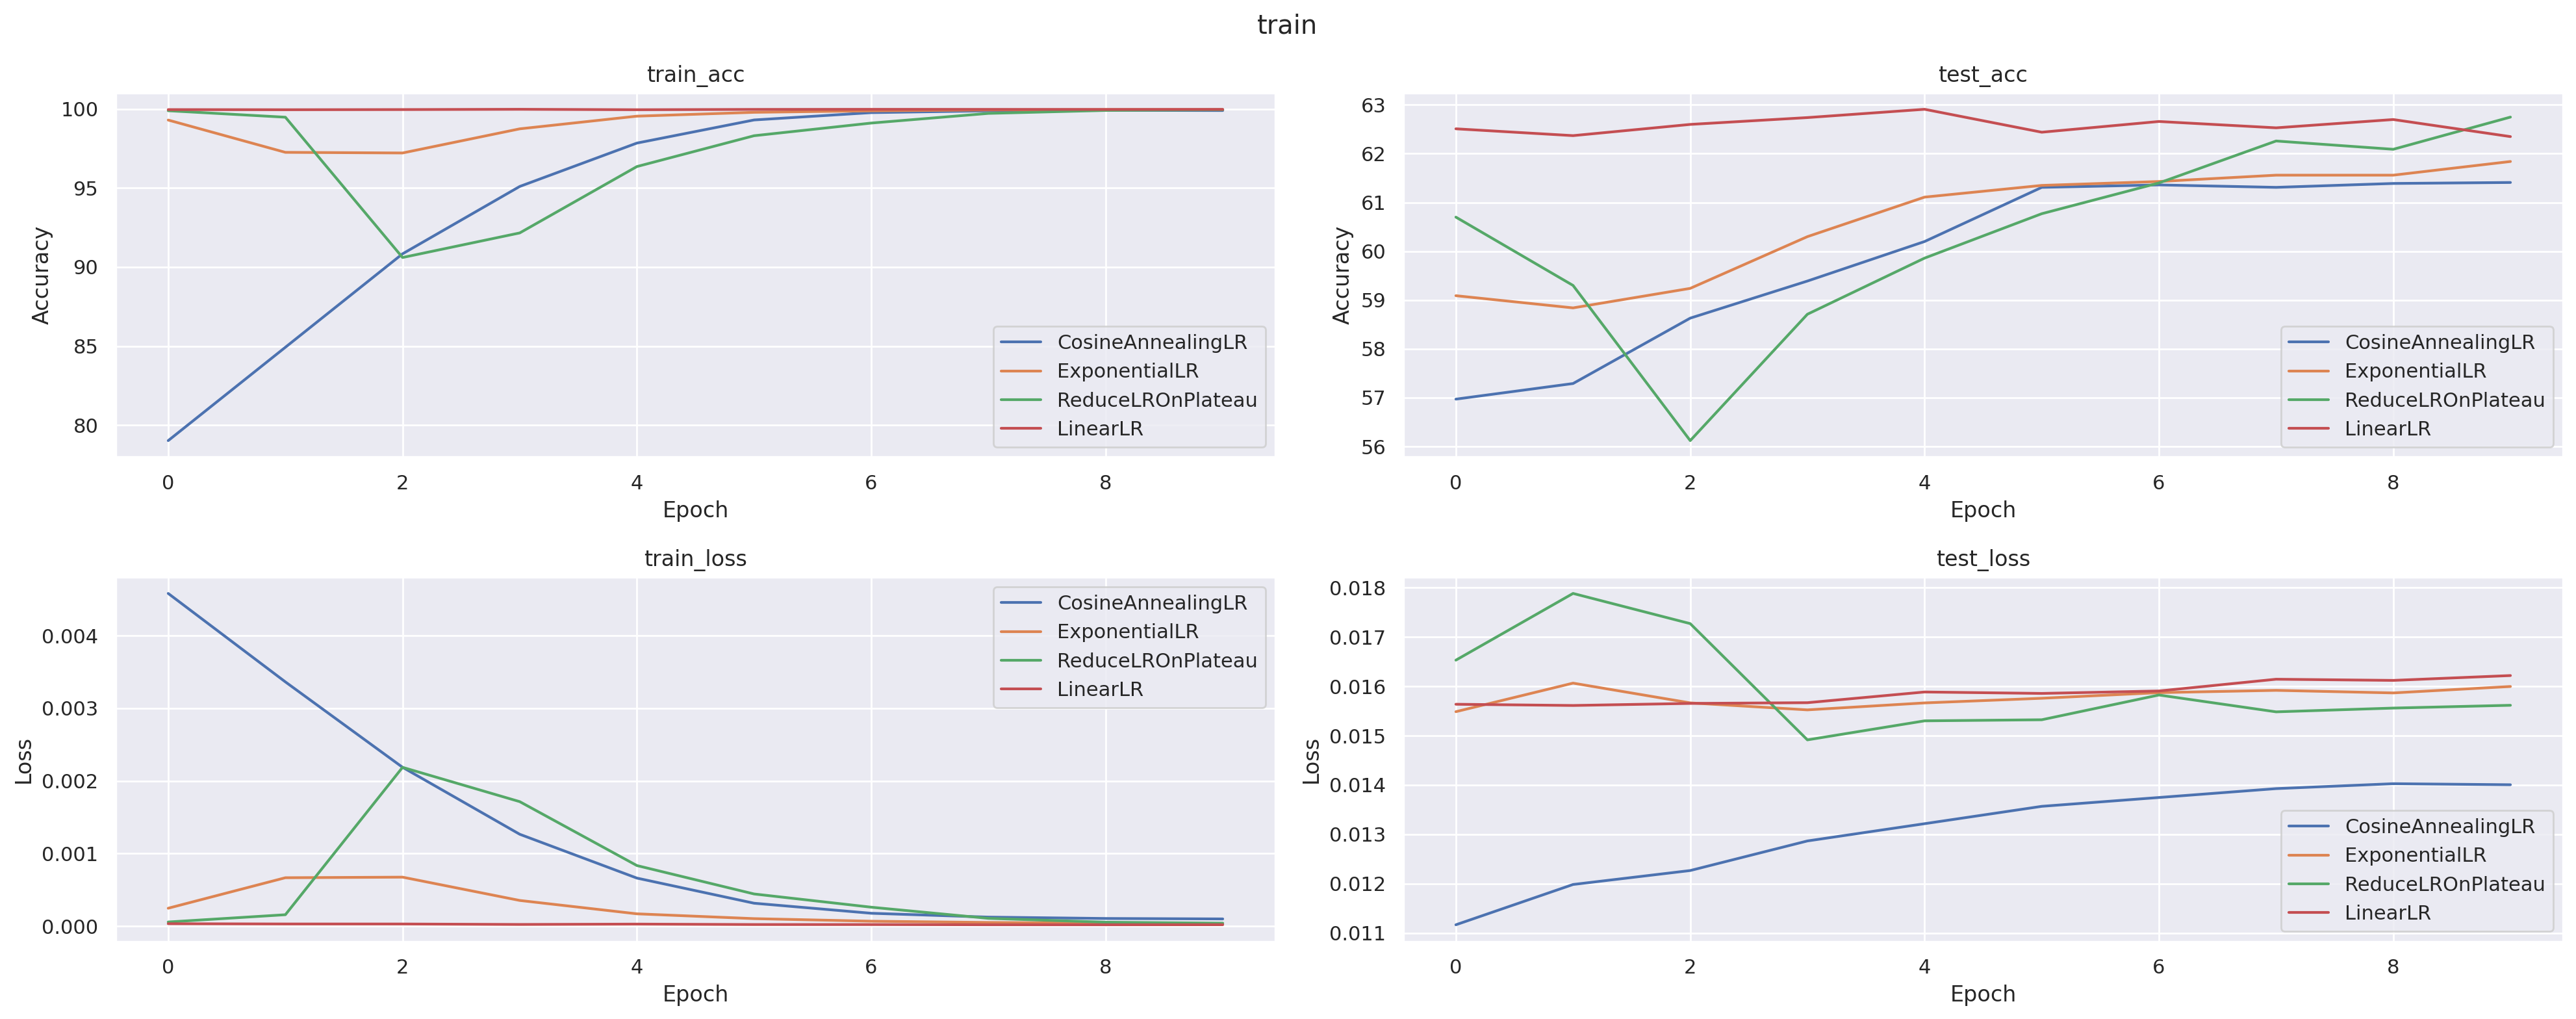

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(20, 8))
grid = np.arange(10)

plot = ["train_acc", "test_acc", "train_loss", "test_loss"]
y_label_list = ["Accuracy", "Accuracy", "Loss", "Loss"]
for i, plot_name in enumerate(plot):

    ax[i//2, i%2].plot(grid, schedulers_list["CosineAnnealingLR"][-1][plot_name], label = "CosineAnnealingLR")
    ax[i//2, i%2].plot(grid, schedulers_list["ExponentialLR"][-1][plot_name], label = "ExponentialLR")
    ax[i//2, i%2].plot(grid, schedulers_list["ReduceLROnPlateau"][-1][plot_name], label = "ReduceLROnPlateau")
    ax[i//2, i%2].plot(grid, schedulers_list["LinearLR"][-1][plot_name], label = "LinearLR")

    ax[i//2, i%2].set_title(plot_name)
    ax[i//2, i%2].set_xlabel('Epoch')
    ax[i//2, i%2].set_ylabel(y_label_list[i])
    ax[i//2, i%2].legend()
fig.suptitle("train")
plt.tight_layout()
plt.show()

Какой `lr_scheduler` показал себя лучше всего?

Лучше всех показал себя ReduceLROnPlateau

Посмотрим, чему научилась наша модель на картинках из тестового датасета. Возьмите для этого модель, которая достигла лучших показателей на тестовом датасете и передайте как параметр в предложенной функции визуализации.

In [36]:
resnet = resnet18(weights=None, num_classes=10)

config = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'scheduler_class': optim.lr_scheduler.ReduceLROnPlateau,
    'scheduler_params': {'mode': 'min', 'factor': 0.5, 'patience': 2},
    'dataset': CIFAR10_dataset,
    'device' : 'cuda',
}

trained_resnet, metrics = trainer(**config)

Epoch 1 / 10 | LR: 1.00e-02 | Train Loss: 0.0130, Train Acc: 39.42% | Test Loss: 0.0115, Test Acc: 46.92% | Time: 29.45s
Epoch 2 / 10 | LR: 1.00e-02 | Train Loss: 0.0102, Train Acc: 53.12% | Test Loss: 0.0106, Test Acc: 51.34% | Time: 28.92s
Epoch 3 / 10 | LR: 1.00e-02 | Train Loss: 0.0087, Train Acc: 60.45% | Test Loss: 0.0104, Test Acc: 53.78% | Time: 29.38s
Epoch 4 / 10 | LR: 1.00e-02 | Train Loss: 0.0075, Train Acc: 66.13% | Test Loss: 0.0094, Test Acc: 58.58% | Time: 28.82s
Epoch 5 / 10 | LR: 1.00e-02 | Train Loss: 0.0064, Train Acc: 71.55% | Test Loss: 0.0095, Test Acc: 58.43% | Time: 29.57s
Epoch 6 / 10 | LR: 1.00e-02 | Train Loss: 0.0052, Train Acc: 76.92% | Test Loss: 0.0099, Test Acc: 58.19% | Time: 28.88s
Epoch 7 / 10 | LR: 5.00e-03 | Train Loss: 0.0042, Train Acc: 81.84% | Test Loss: 0.0103, Test Acc: 59.36% | Time: 29.41s
Epoch 8 / 10 | LR: 5.00e-03 | Train Loss: 0.0024, Train Acc: 90.81% | Test Loss: 0.0103, Test Acc: 61.73% | Time: 28.92s
Epoch 9 / 10 | LR: 5.00e-03 | Tr

In [37]:
def show_model_predictions(model, dataset, num_samples=20, rows=4, cols=5, device='cpu'):
    model.to(device)
    model.eval()

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for i, ax in enumerate(zip(indices, axes)):
        image, label = dataset[i]
        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)

        imshow(image, ax=ax[1], title=f"True: {classes[label]}\nPred: {classes[predicted.item()]}")

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

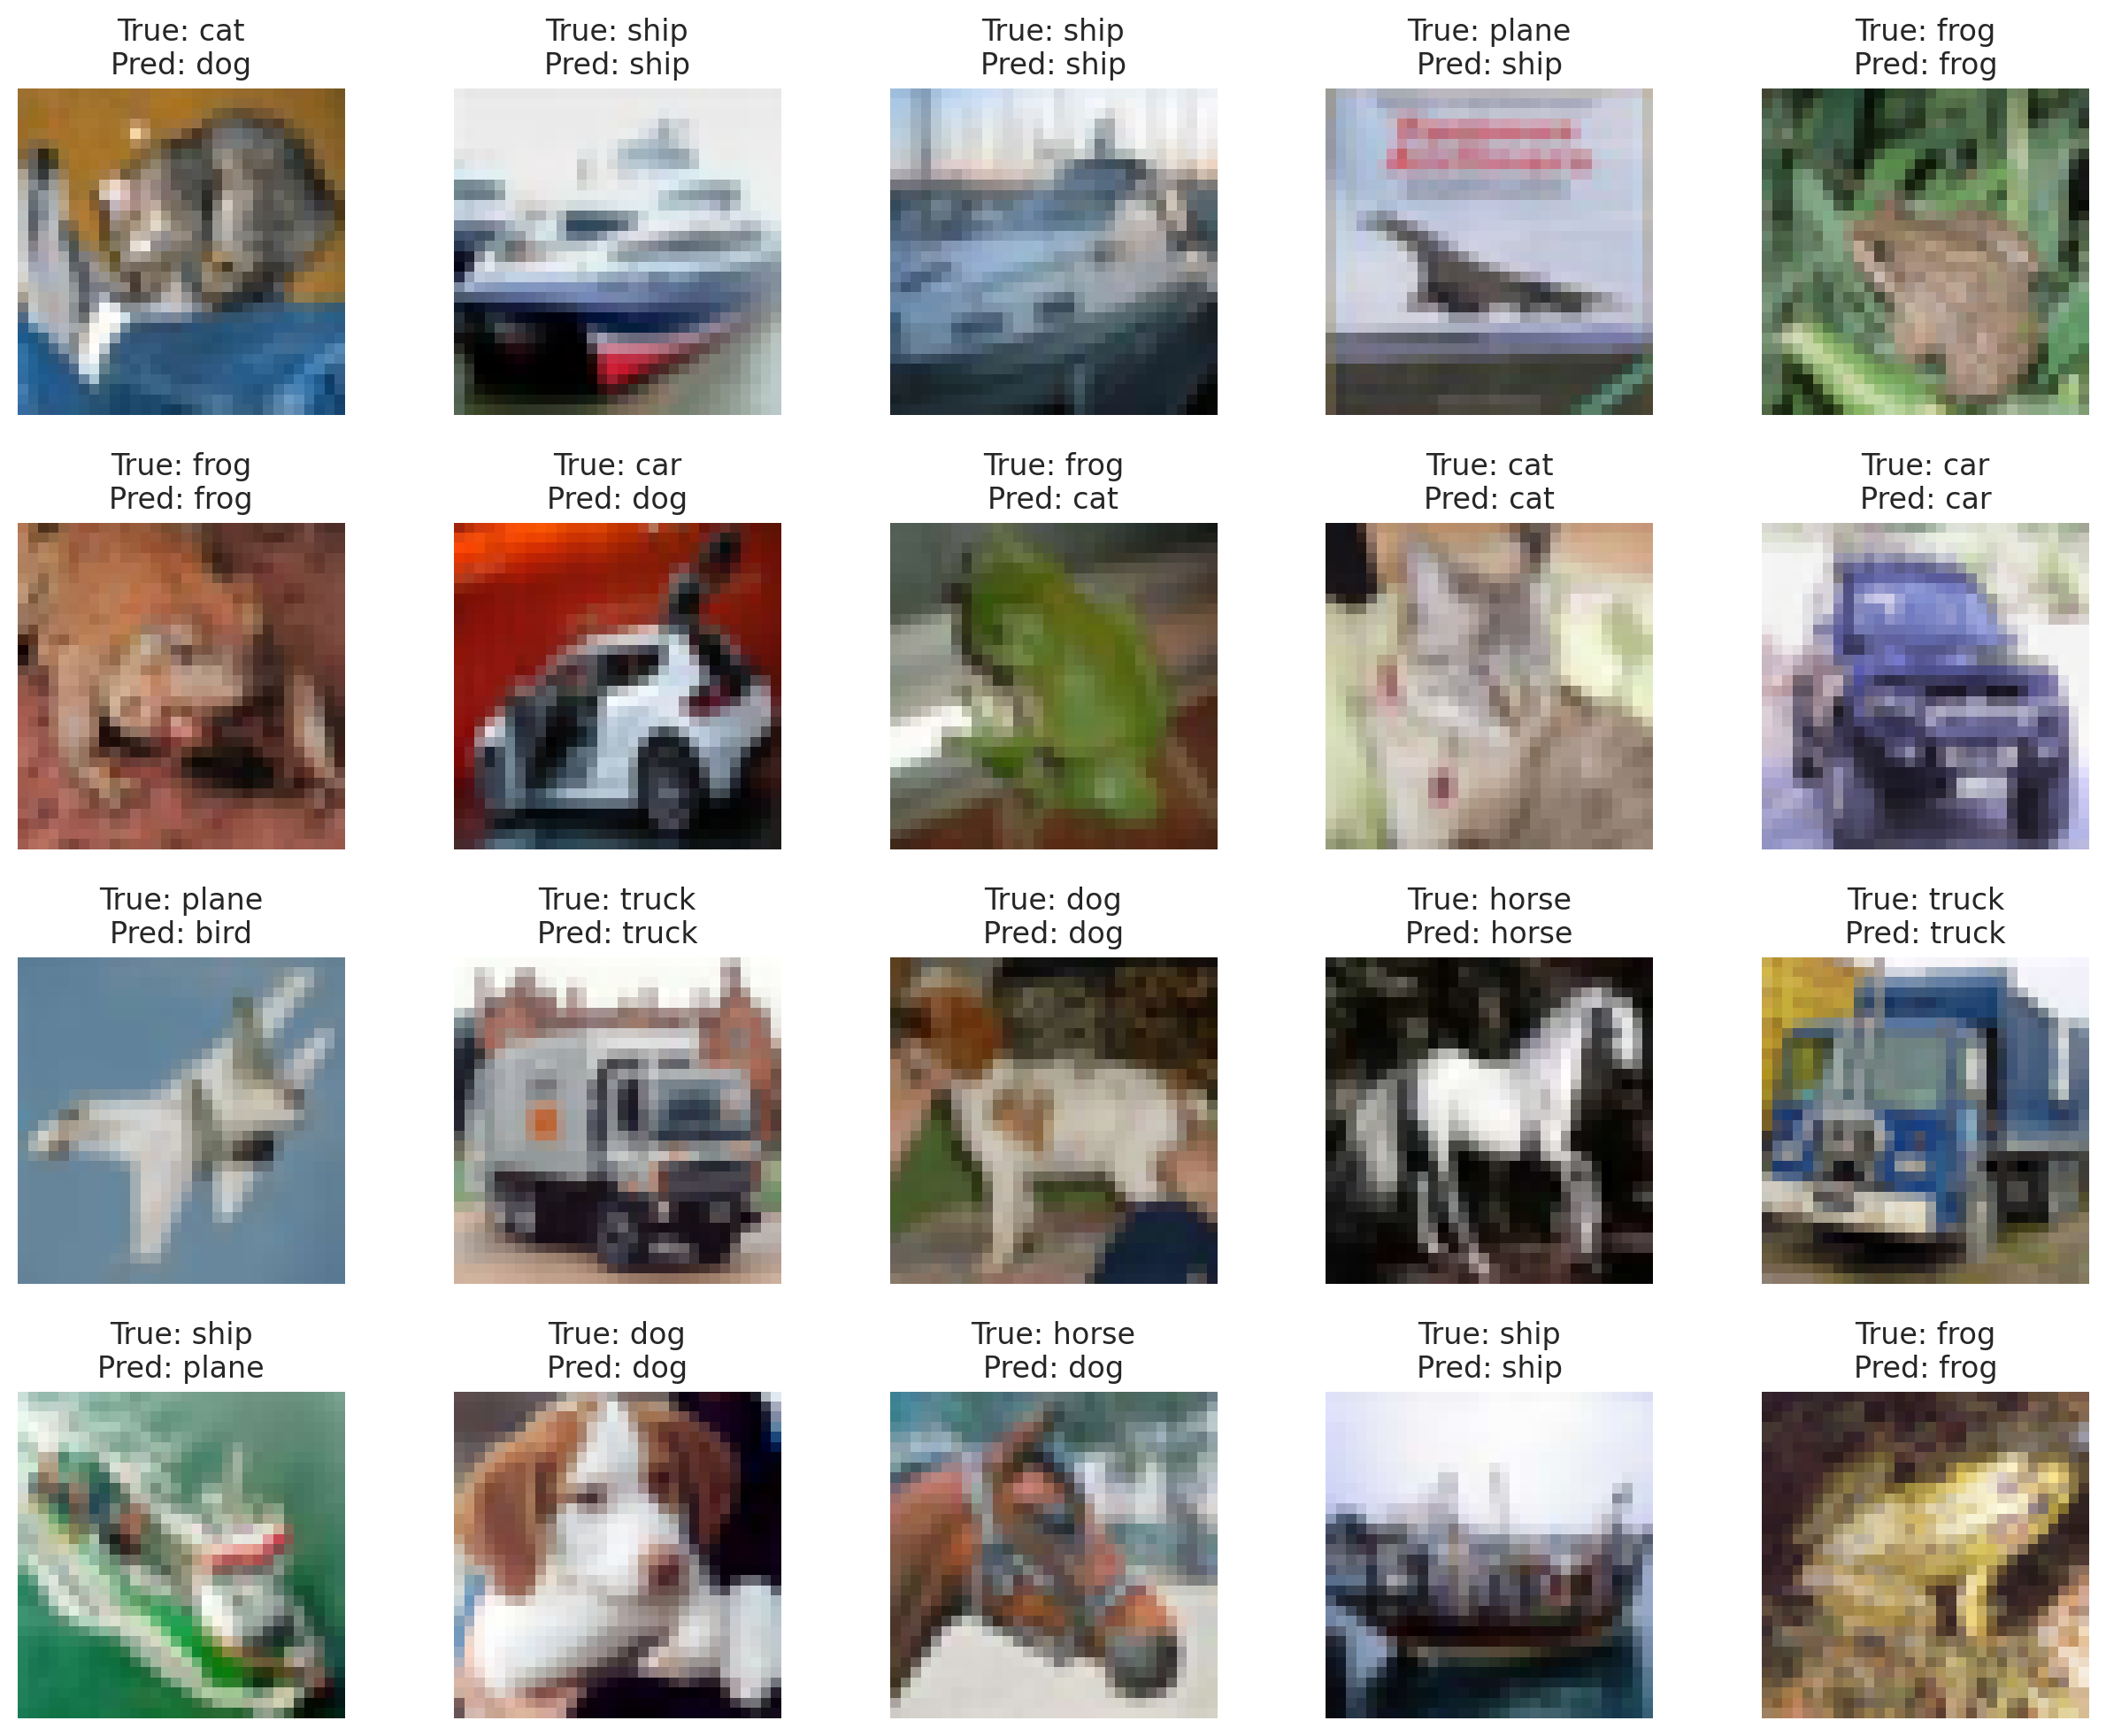

In [38]:
show_model_predictions(
    trained_resnet,
    CIFAR10_dataset.test_dataset,
    num_samples=20,
    rows=4,
    cols=5,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

__б) (5 баллов)__ Реализуйте две [техники](https://proceedings.neurips.cc/paper_files/paper/2020/file/c8cc6e90ccbff44c9cee23611711cdc4-Paper.pdf) перемешивания (shuffling-а), а именно: __RandomReshuffling__ и __ShuffleOnce__. Данные техники позволяют улучшить теоретические и практические сходимости алгоритмов.

1. __RandomReshuffling__ — это метод, при котором данные перемешиваются случайным образом в начале каждой эпохи, обеспечивая более равномерное обновление параметров.

2. __ShuffleOnce__ выполняет перемешивание один раз в начале обучения, что снижает вычислительные затраты при сохранении эффективности сходимости.

Допишите классы, представленные ниже.

In [40]:
class RandomReshufflingSampler(torch.utils.data.Sampler):
    def __init__(self, data_source):
        self.data_source = data_source
        self.num_samples = len(data_source)
        self.indices = np.arange(self.num_samples)

    def __iter__(self):
        np.random.shuffle(self.indices)
        return iter(self.indices)

    def __len__(self):
        return self.num_samples

class ShuffleOnceSampler(torch.utils.data.Sampler):
    def __init__(self, data_source):
        self.data_source = data_source
        self.num_samples = len(data_source)
        self.indices = np.arange(self.num_samples)

        np.random.shuffle(self.indices)

    def __iter__(self):
        return iter(self.indices)

    def __len__(self):
        return self.num_samples


Адаптируем функцию `trainer` для использования сэмплеров. Для этого необходимо поставить `shuffle=None`, чтобы убрать изначальное перемешивание и в качестве параметра `sampler=` передать необходимый сэмплер с параметрами.

In [43]:
def shuffled_trainer(num_epochs, batch_size, model_class, criterion, optimizer_class=SGD,
                     optimizer_params=None, scheduler_class=None, scheduler_params=None, dataset=None,
                     sampler_class=None, sampler_params=None,
                     device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        scheduler_class (optim.lr_scheduler): Класс планировщика скорости обучения
        scheduler_params (dict): Параметры планировщика скорости обучения
        dataset (Dataset): Объект датасета
        sampler_class (utils.data.Sampler): Класс кастомного sampler
        sampler_params (dict) Параметры sampler
        device (str): Устройство для вычислений

    Возвращает:
        model (nn.Module): Обученная модель
        metrics (dict): Словарь с логами
    """

    # Создаем загрузчики данных
    train_loader = DataLoader(
        dataset.train_dataset,
        batch_size=batch_size,
        shuffle=False,  # Используем кастомный sampler вместо shuffle
        sampler=sampler_class(dataset.train_dataset, **(sampler_params or {})) if sampler_class else None
    )
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Инициализируем модель, оптимизатор
    model = model_class.to(device)
    optimizer = optimizer_class(model.parameters(), **(optimizer_params or {}))

    # Инициализируем планировщик
    scheduler = None
    if scheduler_class is not None:
        scheduler = scheduler_class(optimizer, **(scheduler_params or {}))

    # Метрики
    metrics = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "learning_rates": []
    }

    def train_epoch(epoch):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            data = data.float()
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pred = torch.argmax(output, dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. *  (correct / total)
        return train_loss, train_acc

    def test_epoch(epoch):
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                data = data.float()
                output = model(data)
                loss = criterion(output, target)
                running_loss += loss.item()
                pred = torch.argmax(output, dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)
        test_loss = running_loss / len(test_loader.dataset)
        test_acc = 100. * (correct / total)
        return test_loss, test_acc

    # Обучение
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Шаг планировщика

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()

        # Сохраняем метрики
        metrics["train_loss"].append(train_loss)
        metrics["train_acc"].append(train_acc)
        metrics["test_loss"].append(test_loss)
        metrics["test_acc"].append(test_acc)
        metrics["learning_rates"].append(optimizer.param_groups[0]['lr'])

        # Логирование
        elapsed = time.time() - start_time
        print(f"Epoch {epoch + 1} / {num_epochs} | "
              f"LR: {metrics['learning_rates'][-1]:.2e} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"Time: {elapsed:.2f}s")

    # Возвращаем модель и метрики
    return model, metrics

\Запустите обучение без `lr_scheduler` c теми же параметрами, что и ранее, для разлиных шаффлеров.

In [60]:
sampler_dict = {
    "RandomReshuffling": RandomReshufflingSampler,
    "ShuffleOnce": ShuffleOnceSampler,
}

with_sheduler = {}
without_sheduler = {}

In [61]:
for name, sampler in sampler_dict.items():
    model, metrics = shuffled_trainer(
        num_epochs=10,
        batch_size=128,
        model_class=resnet18(weights=None, num_classes=10),
        criterion=nn.CrossEntropyLoss(reduction='mean'),
        optimizer_class=SGD,
        optimizer_params={'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
        scheduler_class=None,
        dataset=CIFAR10_dataset,
        sampler_class=sampler,
        device='cuda'
    )
    without_sheduler[name] = metrics

Epoch 1 / 10 | LR: 1.00e-02 | Train Loss: 0.0130, Train Acc: 39.64% | Test Loss: 0.0114, Test Acc: 46.96% | Time: 28.96s
Epoch 2 / 10 | LR: 1.00e-02 | Train Loss: 0.0102, Train Acc: 52.96% | Test Loss: 0.0101, Test Acc: 53.52% | Time: 29.20s
Epoch 3 / 10 | LR: 1.00e-02 | Train Loss: 0.0088, Train Acc: 60.05% | Test Loss: 0.0096, Test Acc: 56.68% | Time: 28.92s
Epoch 4 / 10 | LR: 1.00e-02 | Train Loss: 0.0075, Train Acc: 65.40% | Test Loss: 0.0098, Test Acc: 56.99% | Time: 29.17s
Epoch 5 / 10 | LR: 1.00e-02 | Train Loss: 0.0064, Train Acc: 71.02% | Test Loss: 0.0102, Test Acc: 56.60% | Time: 28.83s
Epoch 6 / 10 | LR: 1.00e-02 | Train Loss: 0.0053, Train Acc: 76.08% | Test Loss: 0.0100, Test Acc: 58.61% | Time: 29.44s
Epoch 7 / 10 | LR: 1.00e-02 | Train Loss: 0.0043, Train Acc: 80.86% | Test Loss: 0.0109, Test Acc: 58.58% | Time: 28.88s
Epoch 8 / 10 | LR: 1.00e-02 | Train Loss: 0.0033, Train Acc: 85.63% | Test Loss: 0.0111, Test Acc: 58.55% | Time: 29.55s
Epoch 9 / 10 | LR: 1.00e-02 | Tr

Запустите с любым `lr_scheduler`.

In [62]:
for name, sampler in sampler_dict.items():
    model, metrics = shuffled_trainer(
        num_epochs=10,
        batch_size=128,
        model_class=resnet18(weights=None, num_classes=10),
        criterion=nn.CrossEntropyLoss(reduction='mean'),
        optimizer_class=SGD,
        optimizer_params={'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
        scheduler_class=optim.lr_scheduler.ExponentialLR,
        scheduler_params={'gamma': 0.9},
        dataset=CIFAR10_dataset,
        sampler_class=sampler,
        device='cuda'
    )
    with_sheduler[name] = metrics

Epoch 1 / 10 | LR: 9.00e-03 | Train Loss: 0.0128, Train Acc: 40.07% | Test Loss: 0.0112, Test Acc: 48.60% | Time: 29.47s
Epoch 2 / 10 | LR: 8.10e-03 | Train Loss: 0.0102, Train Acc: 52.87% | Test Loss: 0.0103, Test Acc: 52.45% | Time: 28.85s
Epoch 3 / 10 | LR: 7.29e-03 | Train Loss: 0.0087, Train Acc: 60.06% | Test Loss: 0.0100, Test Acc: 54.63% | Time: 29.40s
Epoch 4 / 10 | LR: 6.56e-03 | Train Loss: 0.0075, Train Acc: 66.09% | Test Loss: 0.0095, Test Acc: 58.14% | Time: 28.79s
Epoch 5 / 10 | LR: 5.90e-03 | Train Loss: 0.0063, Train Acc: 71.59% | Test Loss: 0.0095, Test Acc: 58.37% | Time: 29.05s
Epoch 6 / 10 | LR: 5.31e-03 | Train Loss: 0.0052, Train Acc: 77.02% | Test Loss: 0.0098, Test Acc: 59.03% | Time: 29.03s
Epoch 7 / 10 | LR: 4.78e-03 | Train Loss: 0.0041, Train Acc: 82.39% | Test Loss: 0.0105, Test Acc: 57.50% | Time: 28.76s
Epoch 8 / 10 | LR: 4.30e-03 | Train Loss: 0.0032, Train Acc: 87.04% | Test Loss: 0.0106, Test Acc: 58.89% | Time: 29.08s
Epoch 9 / 10 | LR: 3.87e-03 | Tr

Постройте сравнительные графики сходимости.

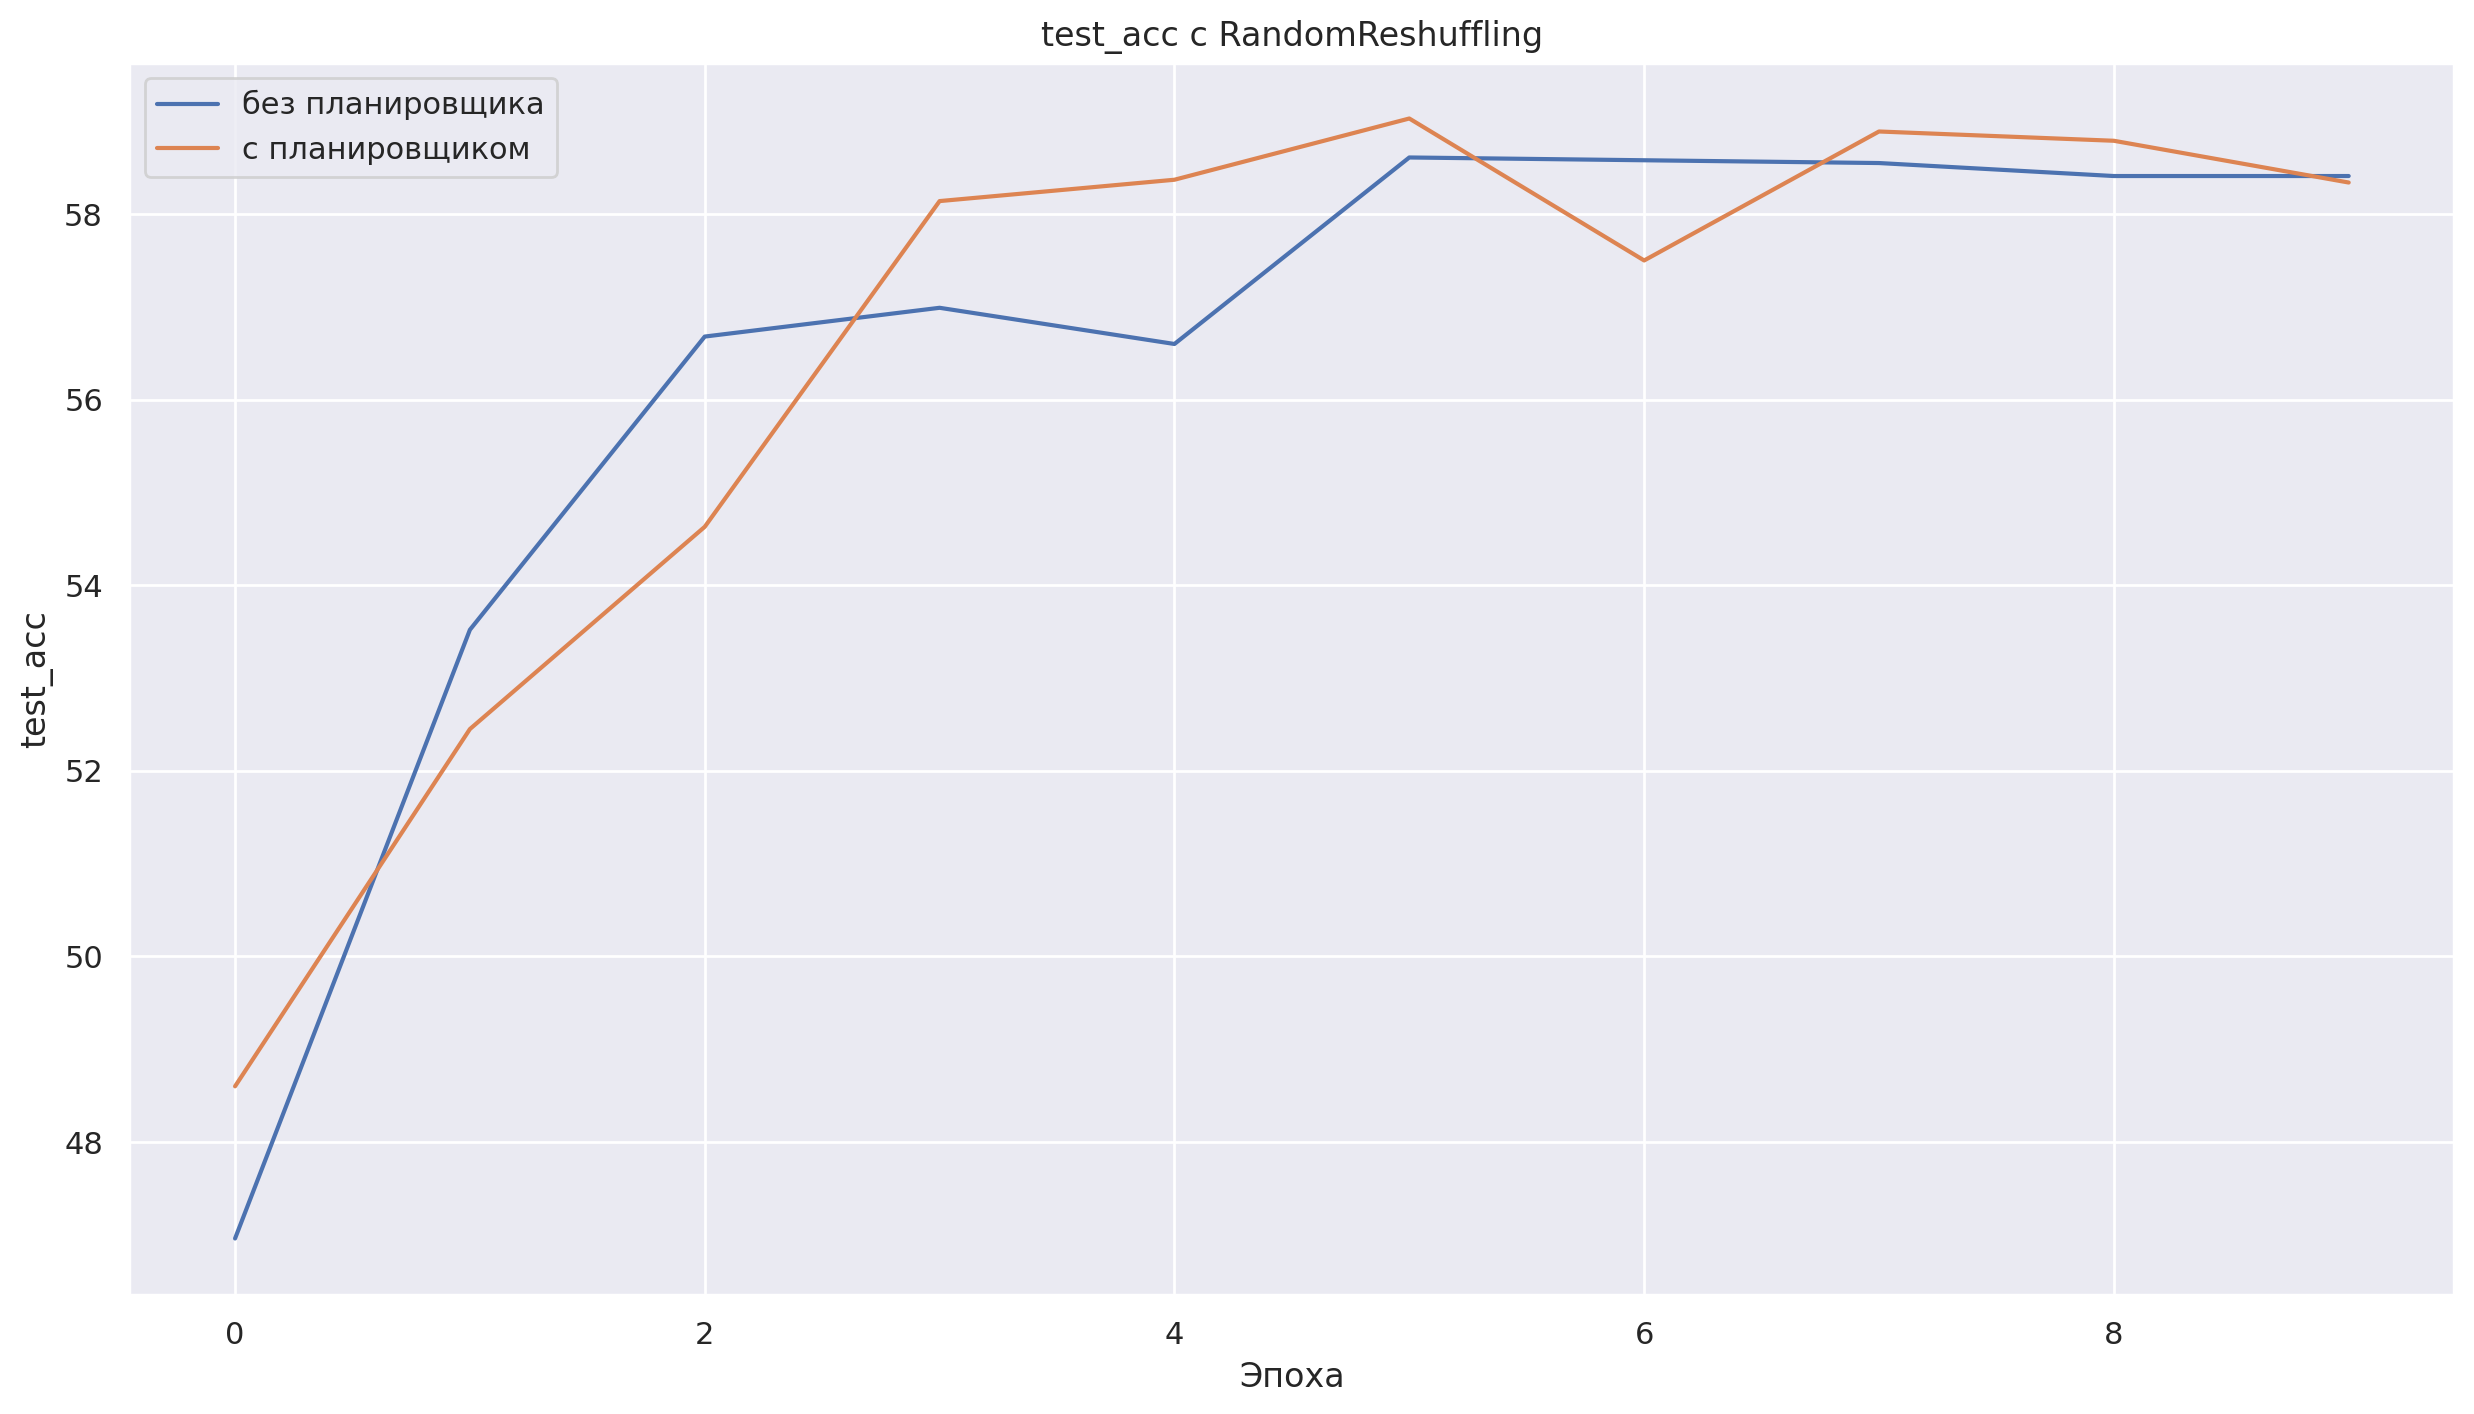

In [63]:
plt.figure(figsize=(15, 8))
plt.plot(without_sheduler["RandomReshuffling"]["test_acc"], label='без планировщика')
plt.plot(with_sheduler["RandomReshuffling"]["test_acc"], label='с планировщиком')
plt.xlabel('Эпоха')
plt.ylabel("test_acc")
plt.title("test_acc c RandomReshuffling")
plt.legend()
plt.show()

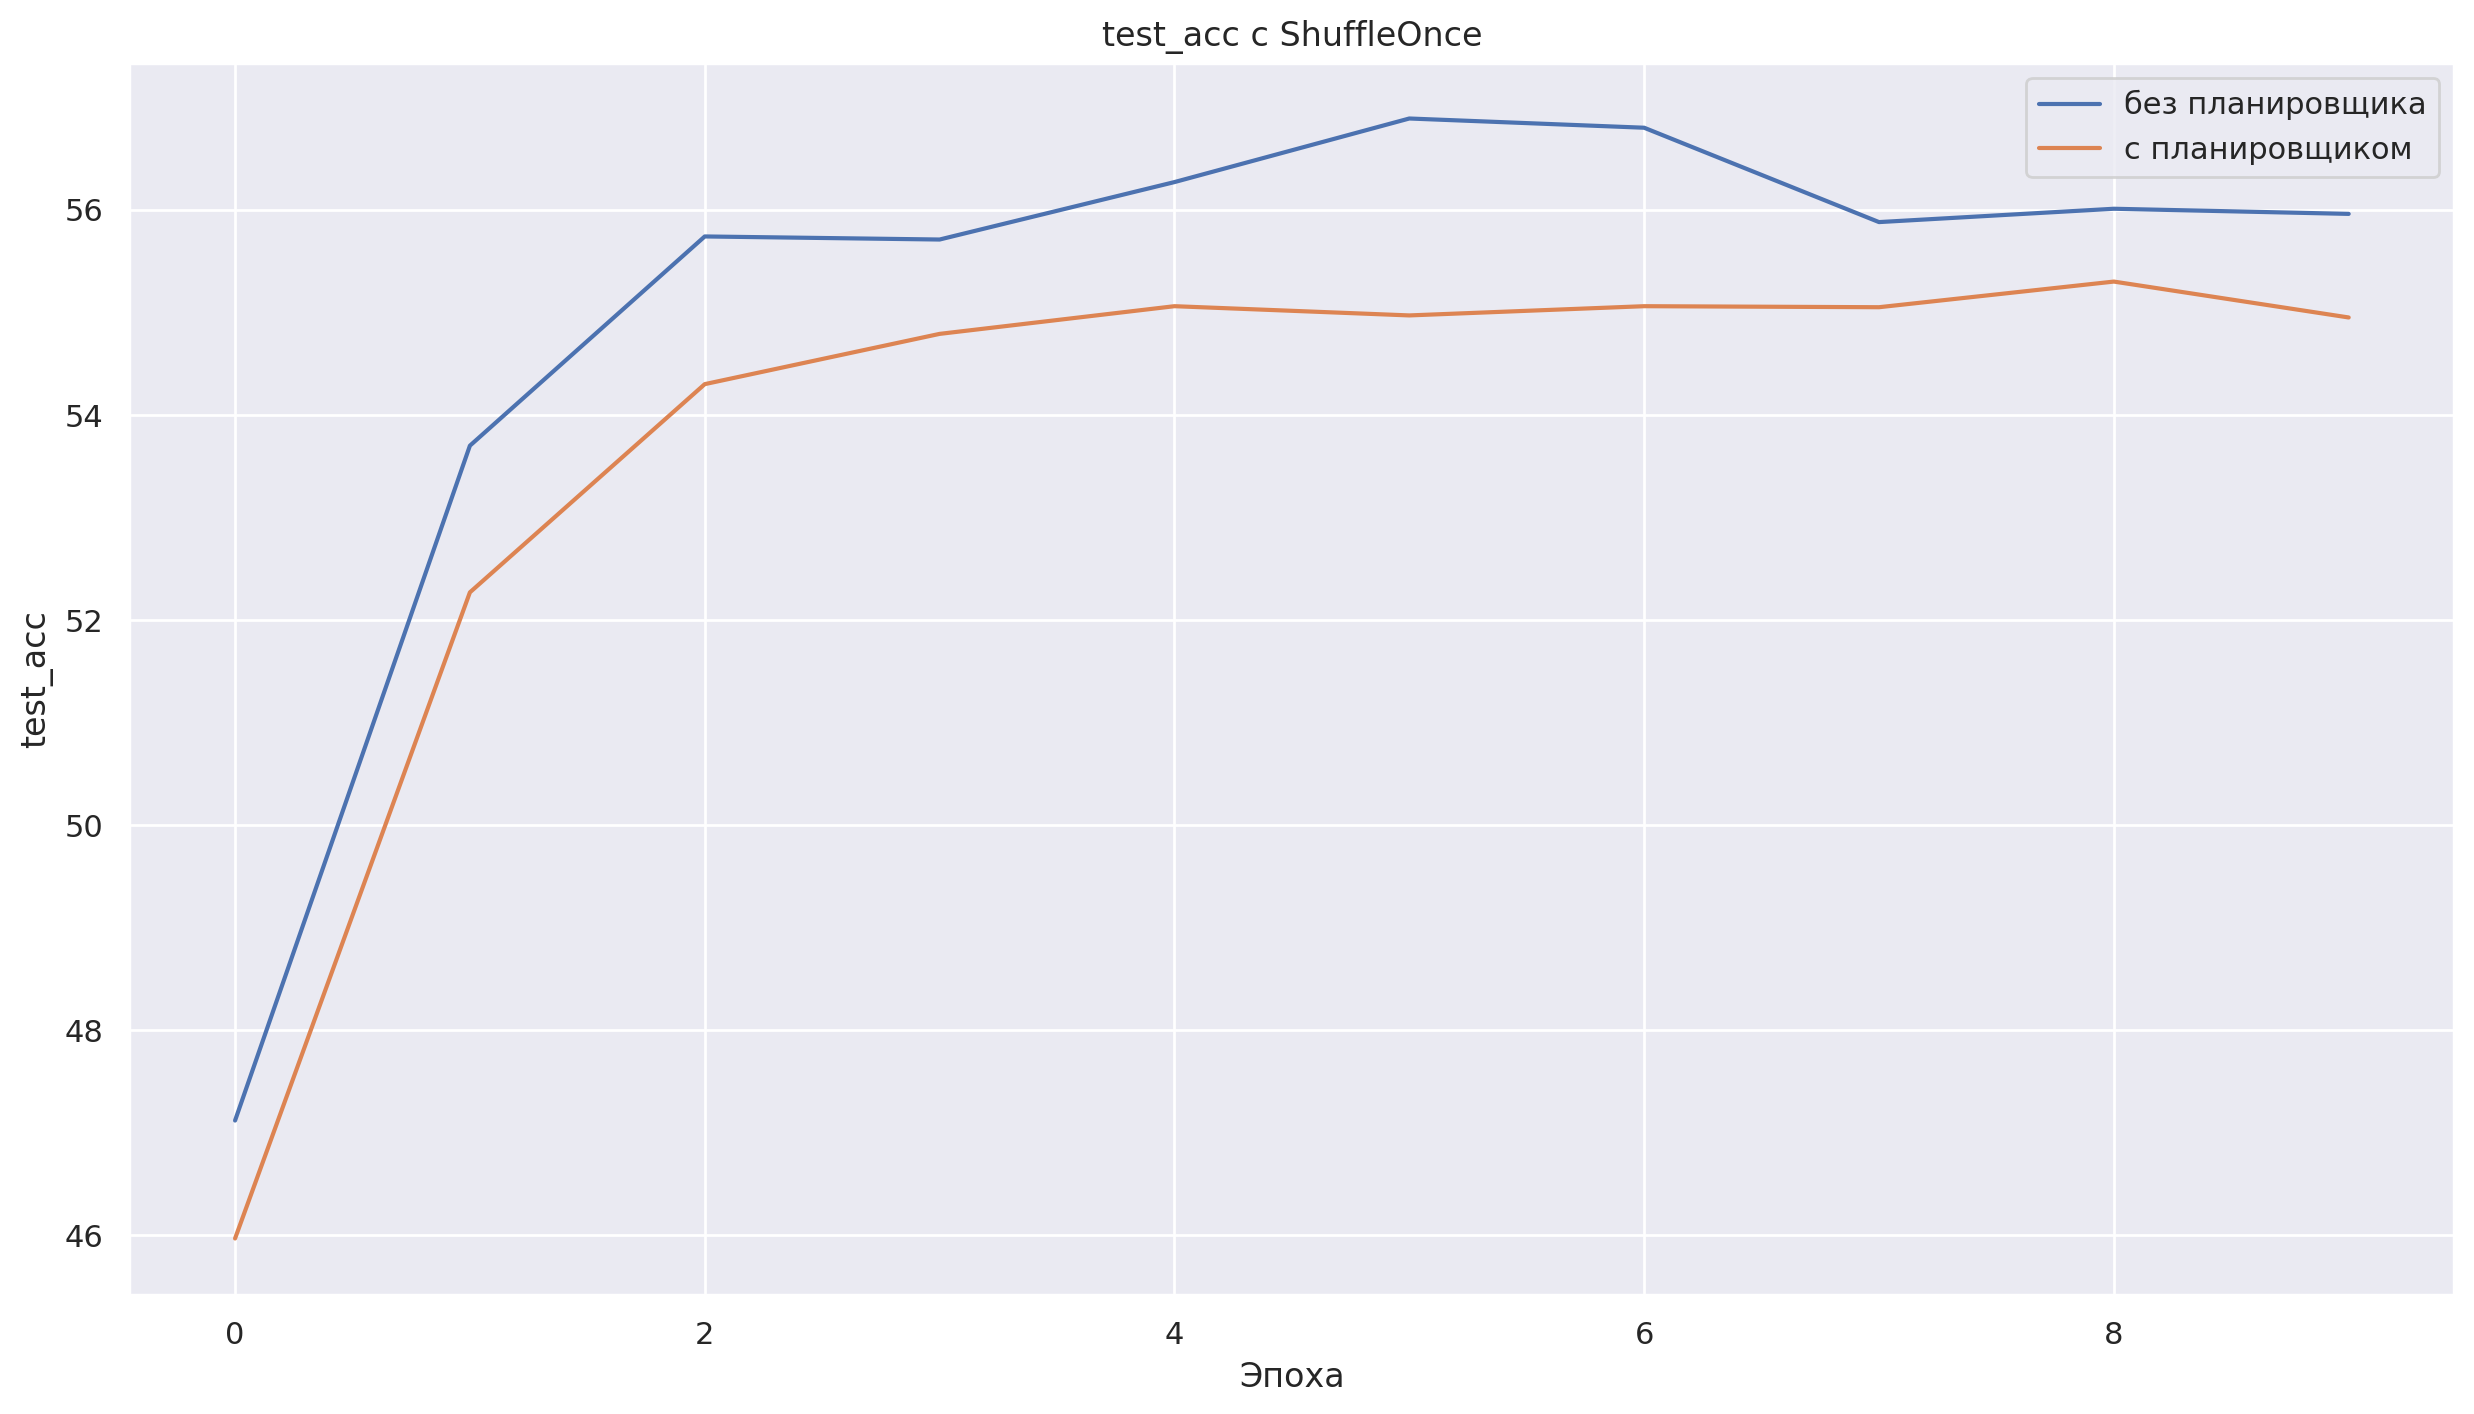

In [64]:
plt.figure(figsize=(15, 8))
plt.plot(without_sheduler["ShuffleOnce"]["test_acc"], label='без планировщика')
plt.plot(with_sheduler["ShuffleOnce"]["test_acc"], label='с планировщиком')
plt.xlabel('Эпоха')
plt.ylabel("test_acc")
plt.title("test_acc c ShuffleOnce")
plt.legend()
plt.show()

Дает ли данная техника улучшение?

RandomReshuffler вместе с планировщиком дает чуть более лучшую точность